# <img src="https://epfl-ada.github.io/assets/img/ada.svg" width="40" /> Digital Tribes: The Universal Language of Online Hostility

## Analyzing Cross-Community Interactions on Reddit

---

### Research Question

**Do online "tribes", whether political or sports-related, exhibit universal patterns of hostility when interacting with rival communities?**

Reddit provides a unique lens into tribal behavior. When users from one community (subreddit) post links mentioning another community, the sentiment of that interaction can be classified as positive, neutral, or negative. We hypothesize that:

1. Political communities are more hostile than sports communities
2. Despite frequency differences, the *linguistic markers* of hostility are universal
3. Major events (elections, championships) temporarily amplify hostility but don't fundamentally change behavior

### Key Findings Preview

| Finding | Evidence |
| ------- | -------- |
| Politics is 3.3x more hostile than sports | 17.3% vs 5.2% negative rate |
| Hostility "sounds" the same across domains | r = 0.937 LIWC correlation |
| Cross-domain classifiers transfer successfully | AUC well above random baseline |
| Events cause temporary spikes, not permanent change | Behavior returns to baseline |

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Methods: Clustering & Camp Definitions](#2-methods-clustering--camp-definitions)
3. [Results](#3-results)
   - 3.1 Baseline Hostility Comparison
   - 3.2 Camp-to-Camp Interaction Patterns
   - 3.3 The Universal Hostility Signature
   - 3.4 Tribal Identity: Pronoun Analysis
   - 3.5 Network Structure: Aggressors vs Targets
   - 3.6 Event Impact Analysis
4. [Statistical Validation](#4-statistical-validation)
   - 4.1 Proportion Tests & Effect Sizes
   - 4.2 Cross-Domain Classifier Transfer
   - 4.3 Logistic Regression Coefficients
   - 4.4 Bootstrap & Permutation Tests
   - 4.5 Difference-in-Differences
   - 4.6 Network Metrics
5. [Conclusion](#5-conclusion)

---

# 1. Setup & Data Loading

We begin by loading the necessary libraries and datasets. All analysis logic is encapsulated in the `results_helpers` module, which wraps functions from our core analysis modules (`data_preparation`, `interaction_analysis`, `event_analysis`, `statistical_analysis`).

In [1]:
from src.results_helpers import *
initialize_plotting()

### 1.1 Dataset Overview

Our analysis uses a Reddit cross-community interaction dataset spanning **January 2014 to April 2017**. Each record represents a post from one subreddit that contains a link to another subreddit, along with:

- **LINK_SENTIMENT**: The sentiment of the interaction (-1 = negative/hostile, 0 = neutral, 1 = positive)
- **LIWC features**: 64 psycholinguistic markers from the Linguistic Inquiry and Word Count dictionary, capturing categories like anger, certainty, pronouns, and cognitive processes
- **Text structure features**: Character counts, word counts, punctuation patterns
- **VADER sentiment scores**: Compound, positive, negative, and neutral sentiment ratios

The data is filtered into two domains: **politics** and **sports**.

In [2]:
data = load_all_data()

Loading datasets...
✓ Raw body posts:        286,561
✓ Raw title posts:       571,927
✓ Subreddit embeddings:  51,278
✓ Politics posts:        40,015
✓ Sports posts:          27,727
✓ Total for analysis:    67,742
✓ Events defined:        14

Date range: 2013-12-31 to 2017-04-30
Features per post: 65 LIWC + 18 text + 3 sentiment


---

# 2. Methods: Clustering & Camp Definitions

To study tribal behavior, we need to group subreddits into meaningful "camps", which are clusters of ideologically or thematically aligned communities. This allows us to move beyond individual subreddit interactions to understand broader tribal dynamics.

## 2.1 Approach: Embedding-Based Clustering

Each subreddit is represented as a **300-dimensional embedding vector**. These embeddings capture semantic similarity: subreddits that discuss similar topics or attract similar users have similar embeddings.

Our clustering approach:

1. Dimensionality Reduction (PCA): Lower dimensional space to make clustering more efficient, while retaining most of the variance in the data
2. **K-means clustering**: Group similar subreddits into coherent clusters
3. **Domain expertise**: Refine clusters with manual labeling based on subreddit content
4. **Cosine similarity**: Find subreddits most similar to known "seed" communities (e.g., find communities similar to r/nfl)

This hybrid approach combines data-driven clustering with human judgment to create meaningful analytical categories.

PCA explained variance ratio: 94.22%


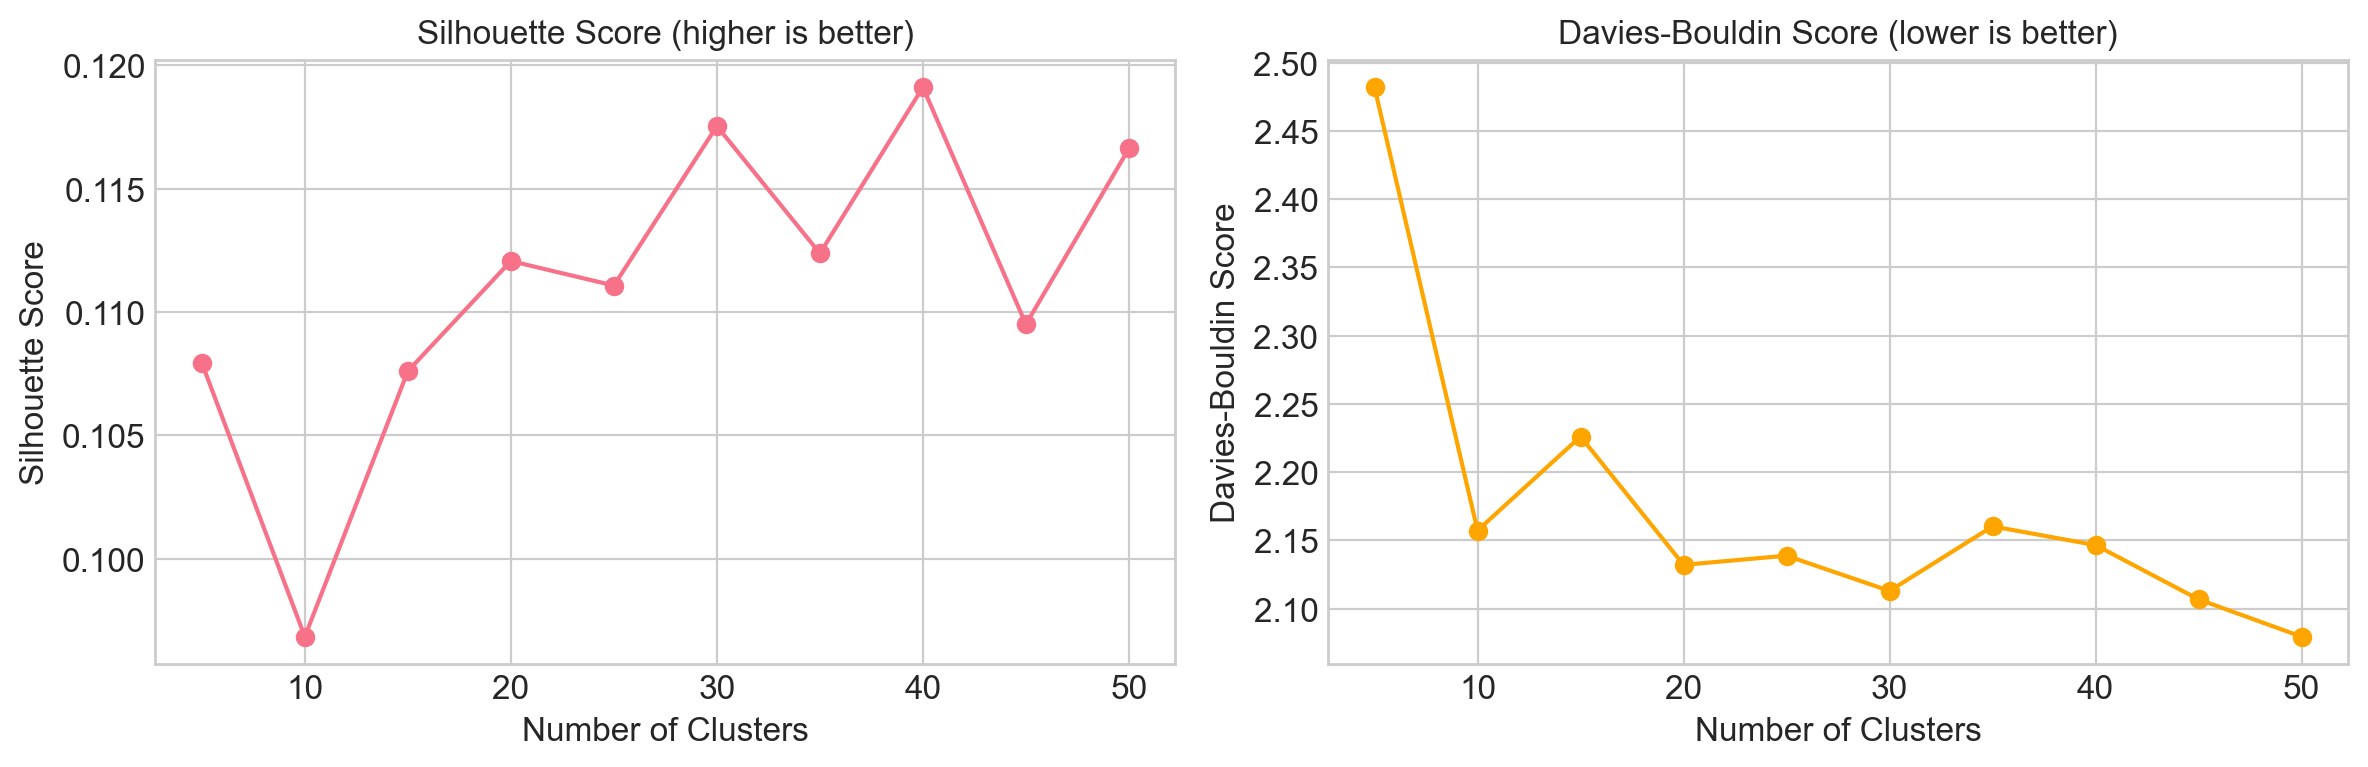

In [3]:
show_pca_and_clustering_score(data)

For the clustering, we were able to retain **94.22% of data variance**. To choose the number of clusters, **Silhouette and Davies-Bouldin scores** were plotted and allowed us to see that 20 clusters had the most significant improvement while still being a small enough number. \
After clustering, the sports and politics lists were hand-picked, but we needed to increase the number of total subreddits for analysis.

To do this, we had to find the nearest neighbors to the manually picked subreddits and visualize them. We've tried two methods:
- Centroid-based similarity: computes the average embedding of the seed subreddits and finds subreddits closest to this centroid.
- Max similarity: finds subreddits that are closest to any of the seed subreddits.

We found that the second method yields better results. Some subreddits from the same category are not very close to each other in the embedding space, so averaging their embeddings can lead to a centroid that doesn't represent any of them well. The max similarity method ensures that we find subreddits that are closely related to at least one of the seeds, leading to more relevant results.

## 2.2 Camp Definitions

We define camps based on ideological alignment (for politics) or team/league affiliation (for sports). Each camp contains subreddits that share a common perspective or fan base.

**Political camps** include:
- `trump_conservative`: Pro-Trump and conservative subreddits
- `anti_trump`: Explicitly anti-Trump communities
- `progressive`: Left-leaning and socialist communities
- `meta_drama`: Drama-focused communities that observe and comment on conflicts
- And several others covering libertarian, conspiracy, and moderate perspectives

**Sports camps** include:
- NFL divisions (e.g., `afc_east`, `nfc_south`)
- NBA divisions
- Soccer leagues and teams
- Meta-sports communities

In [4]:
show_camp_definitions()

POLITICAL CAMPS

trump_conservative (7 subreddits):
  the_donald, conservative, republican, hillaryforprison... (+3 more)

libertarian (6 subreddits):
  anarcho_capitalism, libertarian, goldandblack, shitstatistssay... (+2 more)

progressive (7 subreddits):
  sandersforpresident, wayofthebern, kossacks_for_sanders, stillsandersforpres... (+3 more)

anti_trump (6 subreddits):
  enoughtrumpspam, enough_sanders_spam, shitrconservativesays, circlebroke2... (+2 more)

alt_right (5 subreddits):
  european, whiterights, uncensorednews, postnationalist... (+1 more)

conspiracy (3 subreddits):
  conspiracy, conspiratard, undelete

news_mainstream (8 subreddits):
  politics, worldpolitics, worldnews, news... (+4 more)

gender_politics (3 subreddits):
  mensrights, theredpill, againstmensrights

meta_drama (7 subreddits):
  subredditdrama, drama, bestof, shitliberalssay... (+3 more)

SPORTS CAMPS (showing first 6)

nfl_general (3 subreddits):
  nfl, nfl_draft, fantasyfootball

afc_east (4 subredd

### Camp Coverage

A key question is: how much of our data is covered by these camp definitions? Posts from "other" subreddits (not assigned to any camp) are excluded from camp-level analysis but included in domain-level analysis.

In [5]:
show_camp_coverage(data)

Camp Assignment Coverage
Politics: 66.5% of posts assigned to a camp
Sports:   57.8% of posts assigned to a camp


---

# 3. Results

## 3.1 Baseline Hostility Comparison

Our first analysis compares the baseline rate of hostile interactions between domains. A post is classified as "hostile" if its `LINK_SENTIMENT` is -1, indicating the post mentions the target subreddit in a negative context.

**Why this matters**: If politics and sports have similar hostility rates, it would suggest online hostility is domain-invariant. If they differ dramatically, it raises questions about what drives the difference.

In [6]:
baseline_stats = analyze_baseline_hostility(data)

BASELINE HOSTILITY RATES

Politics: 17.3% of cross-community posts are hostile
Sports:   5.2% of cross-community posts are hostile

→ Politics is 3.3× more hostile than sports


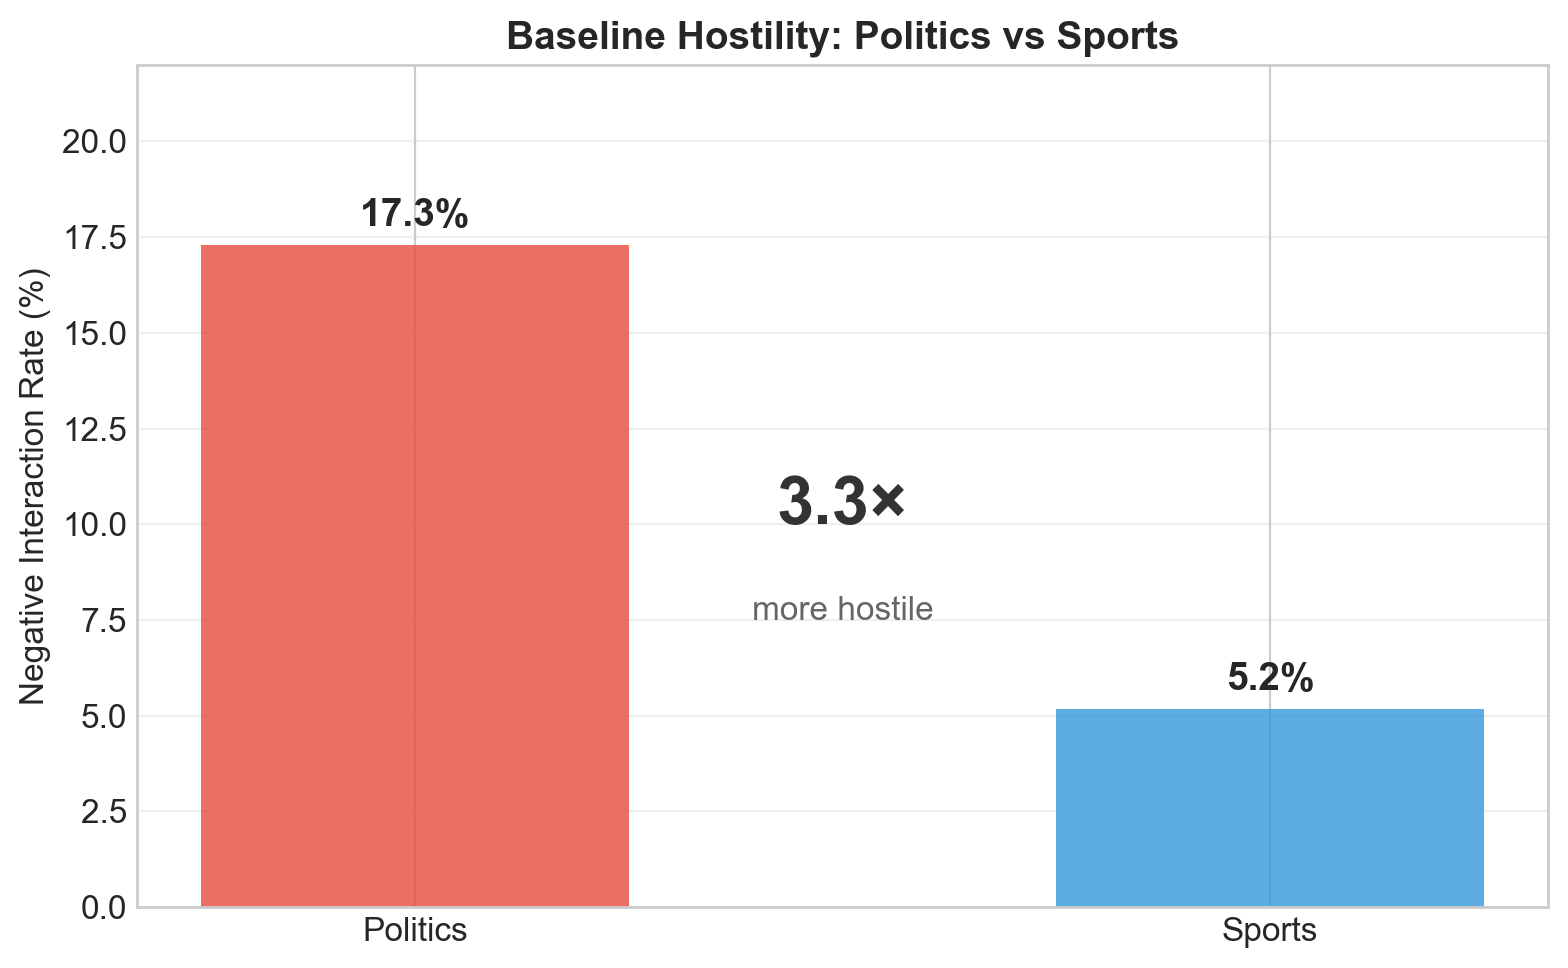

In [7]:
plot_baseline_hostility(data)

### Interpretation

Politics is **3.3 times more hostile** than sports. This is a substantial difference — roughly 1 in 6 political cross-community posts are hostile, compared to 1 in 20 for sports.

Possible explanations:
- **Stakes**: Political outcomes affect lives more directly than sports outcomes
- **Identity**: Political identity is more central to self-concept than sports fandom
- **Polarization**: The 2014-2017 period saw increasing political polarization in the US
- **Content moderation**: Sports communities may have stricter civility norms

But this raises a deeper question: *when posts ARE hostile, do they "sound" different across domains?*

---

## 3.2 Camp-to-Camp Interaction Patterns

Not all camps interact equally. Some camps are consistently hostile toward specific rivals, while others are more broadly aggressive. We visualize this using **interaction heatmaps**. They are matrices where each cell shows the hostility rate from source camp (row) to target camp (column).

**Reading the heatmap**:
- Rows = source camps (who is posting)
- Columns = target camps (who is being mentioned)
- Color = hostility rate (red = more hostile, green = more friendly)
- Values = proportion of posts that are negative

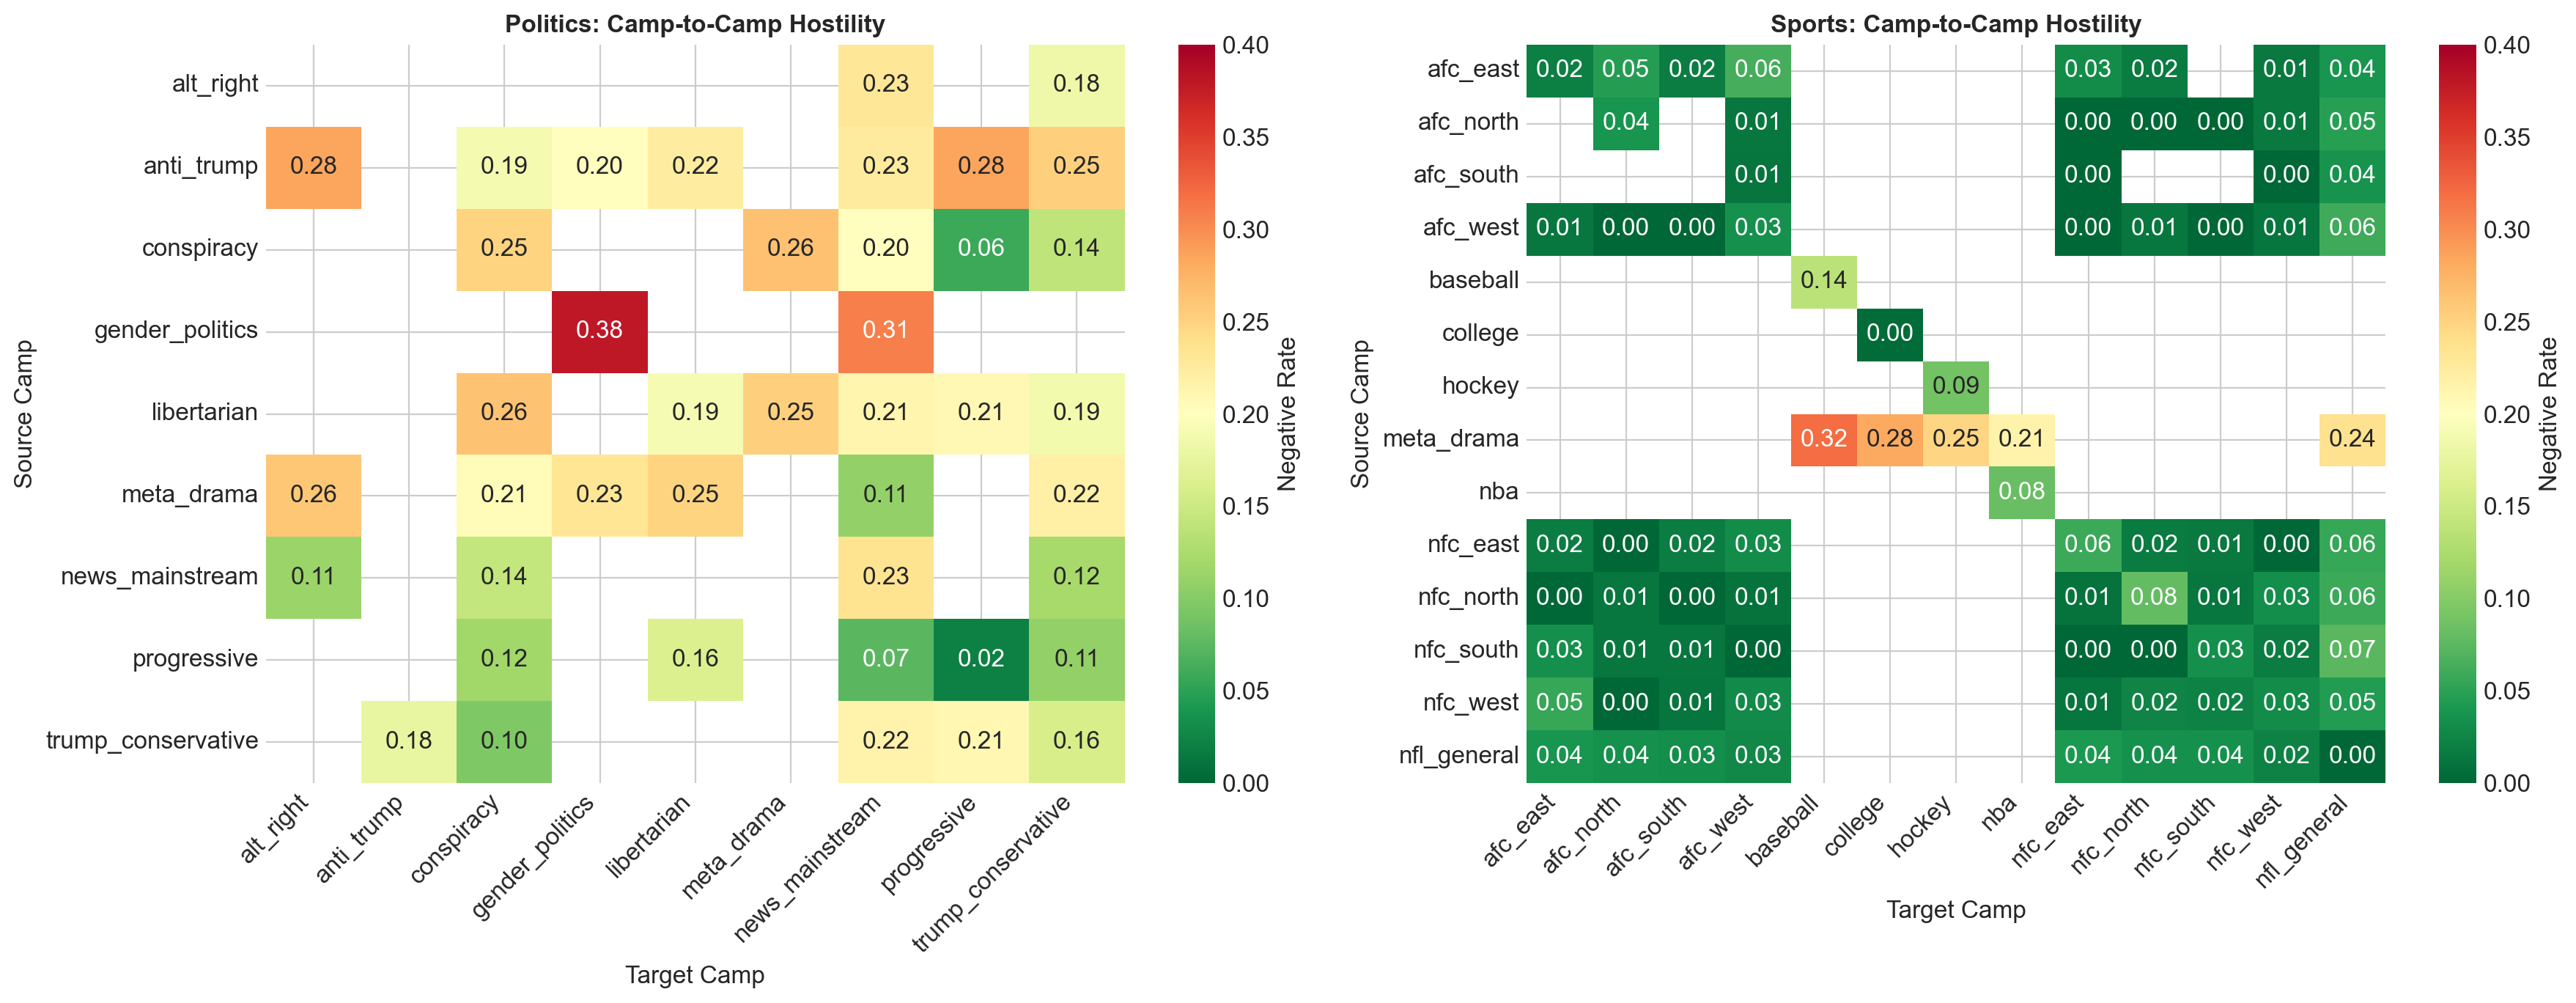

In [8]:
plot_interaction_heatmaps(data)

### Interpretation

**Politics heatmap**: Dominated by oranges and reds. Key observations:
- `meta_drama` (subredditdrama, etc.) is hostile toward almost everyone
- `trump_conservative` and `anti_trump` are mutually hostile
- Even "same-side" camps show some hostility (internal purity tests)

**Sports heatmap**: Mostly green with isolated rivalries:
- NFL divisions show expected rivalries (e.g., AFC East teams)
- Overall hostility is much lower
- `meta_drama` is again notably hostile

The persistence of `meta_drama` as a hostile outlier in BOTH domains is fascinating and suggests that observing and commenting on drama is itself a hostile activity, regardless of content.

In [9]:
show_most_hostile_camps(data)

MOST HOSTILE CAMPS (by outgoing hostility)

Politics - Top 5:
  gender_politics      →  34.3% hostile outgoing
  anti_trump           →  24.6% hostile outgoing
  meta_drama           →  22.4% hostile outgoing
  alt_right            →  21.3% hostile outgoing
  libertarian          →  20.4% hostile outgoing

Sports - Top 5:
  meta_drama           →  24.9% hostile outgoing
  baseball             →  11.8% hostile outgoing
  hockey               →   8.5% hostile outgoing
  nba                  →   8.3% hostile outgoing
  nfc_north            →   3.8% hostile outgoing


---

## 3.3 The Universal Hostility Signature

This is our **core finding**: despite the 3.3× difference in hostility rates, the *linguistic signature* of hostility is nearly identical across domains.

### Method: LIWC Analysis

**LIWC (Linguistic Inquiry and Word Count)** is a validated psycholinguistic dictionary that maps text to psychological categories. For each post, we have 64 LIWC features measuring:

- **Affect**: Positive emotion, negative emotion, anxiety, anger, sadness
- **Cognitive processes**: Certainty, tentative language, causal reasoning
- **Pronouns**: I, we, you, they (markers of self vs. other focus)
- **Social processes**: Family, friends, humans
- **And many more**

We calculate the **hostility signature** as:
$$\text{signature}_{feature} = \bar{x}_{hostile} - \bar{x}_{friendly}$$

This tells us: for each LIWC feature, how much higher (or lower) is it in hostile posts compared to friendly posts?

### The Test

If hostility is domain-specific, politics and sports should have different signatures. If hostility is universal, the signatures should be highly correlated.

In [10]:
liwc_results = analyze_liwc_signatures(data)

THE UNIVERSAL HOSTILITY SIGNATURE

Cross-domain LIWC correlation:
  Pearson r:  0.937
  Spearman ρ: 0.860

→ When posts ARE hostile, they use nearly IDENTICAL vocabulary!


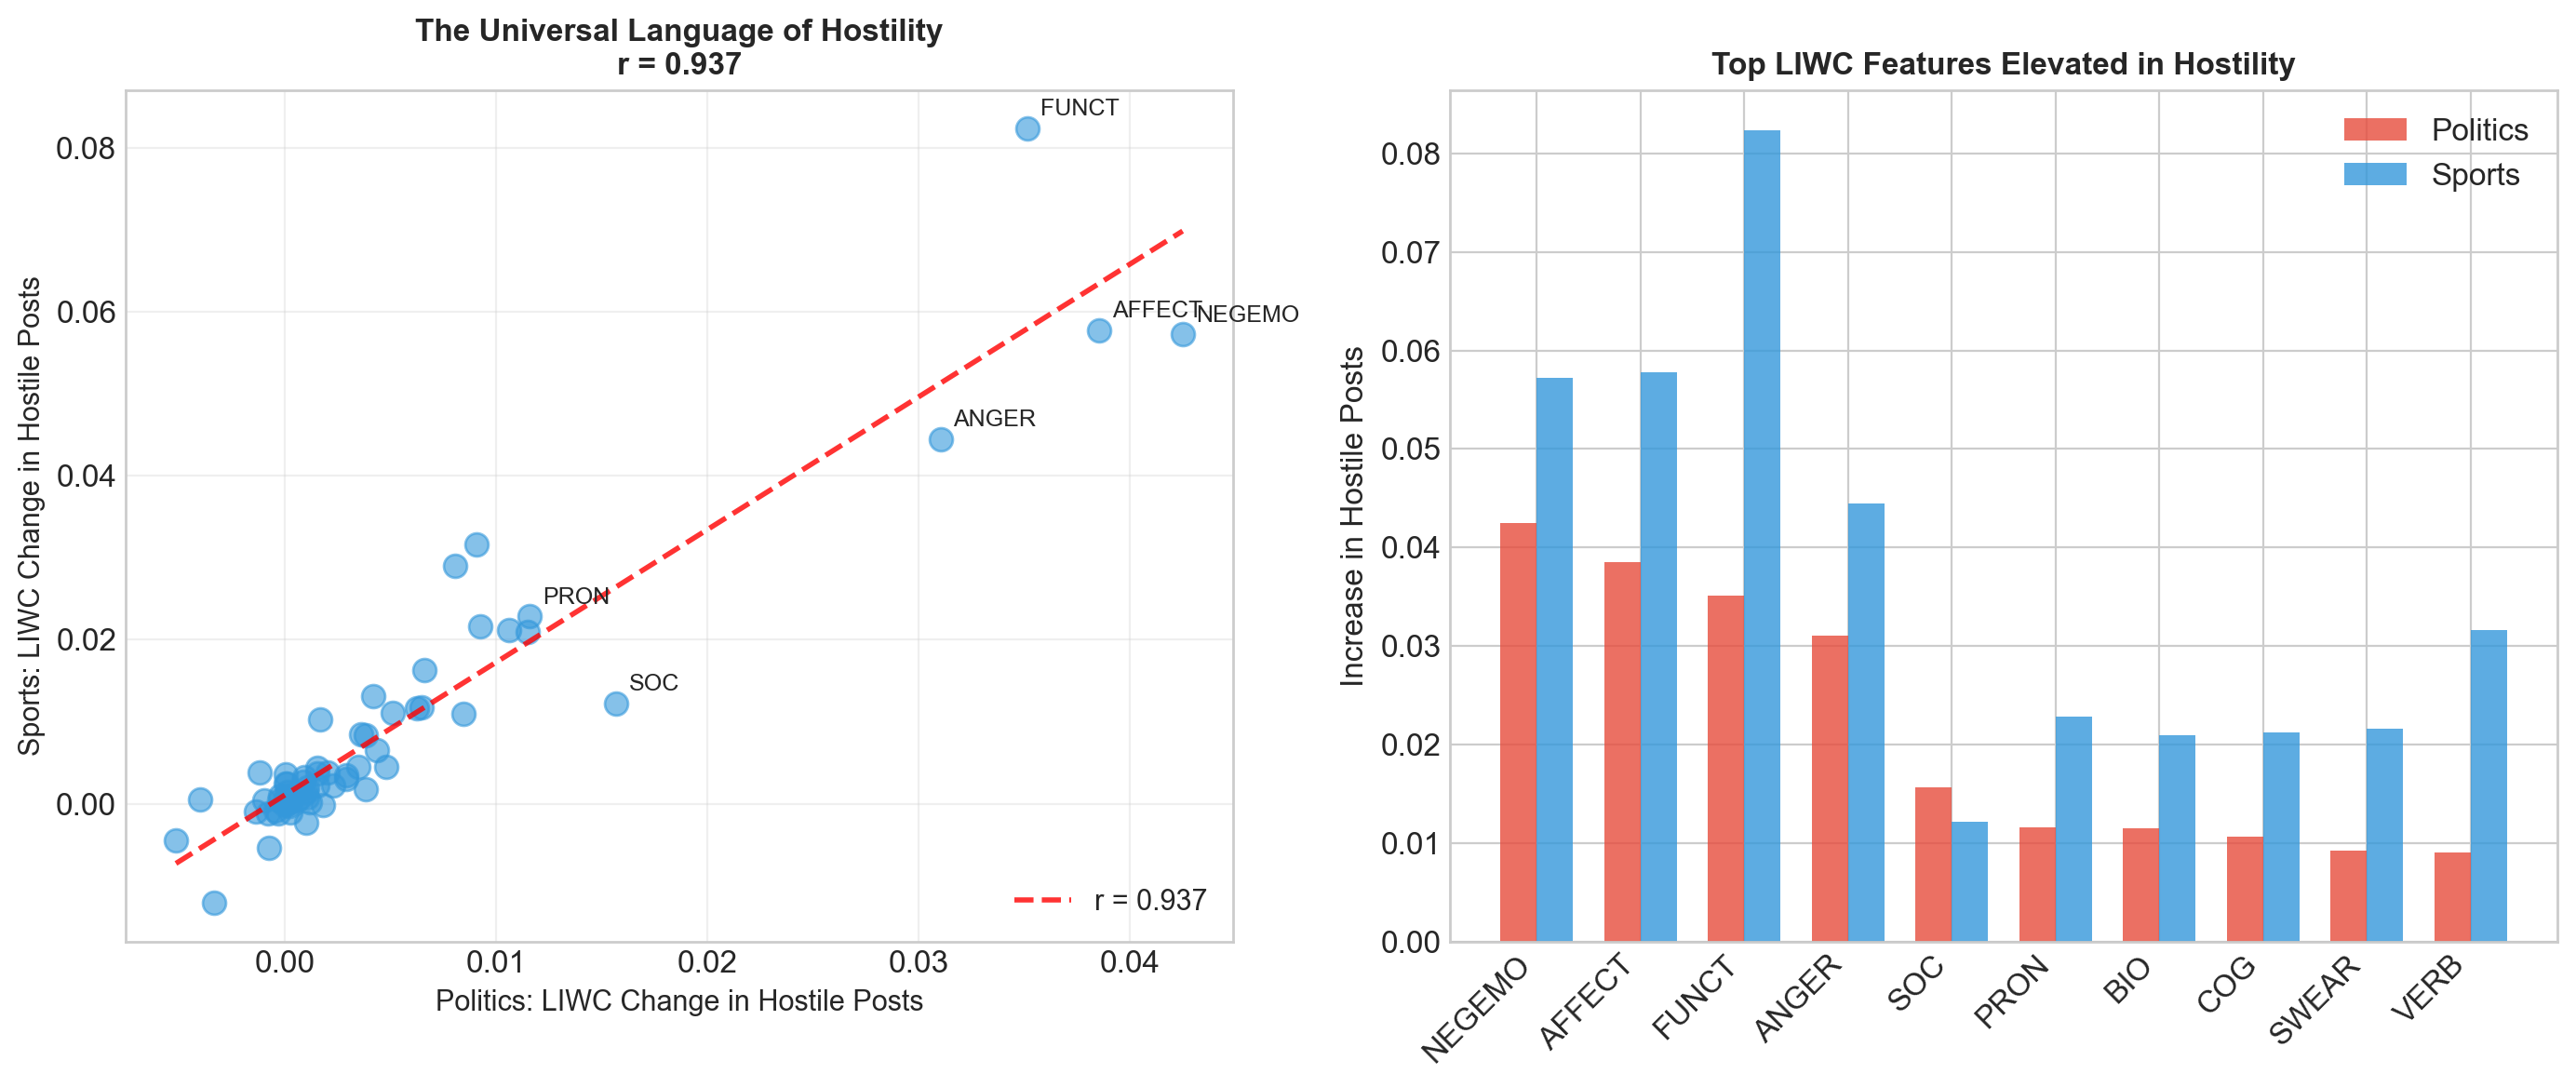

In [11]:
plot_liwc_correlation(data)

### Interpretation

The correlation of **r = 0.937** is remarkably high. This means:

- Features elevated in political hostility are ALSO elevated in sports hostility
- Features reduced in political hostility are ALSO reduced in sports hostility
- The *linguistic fingerprint* of hostility is nearly identical

**What features are elevated in hostility?**
- NEGEMO (negative emotion words)
- ANGER (anger words)
- SWEAR (profanity)
- THEY (out-group pronouns)

**What features are reduced?**
- POSEMO (positive emotion)
- ASSENT (agreement words)

This suggests **hostility is a universal linguistic behavior**. Whether you're attacking a political opponent or a rival sports team, you use the same vocabulary of conflict.

In [12]:
show_top_hostile_features(data)

TOP FEATURES ELEVATED IN HOSTILE POSTS

Feature             Politics       Sports
----------------------------------------
SWEAR                +0.0093      +0.0216
ANGER                +0.0310      +0.0445
PRES                 +0.0081      +0.0290
FUNCT                +0.0351      +0.0823
COG                  +0.0106      +0.0212
NEGEMO               +0.0425      +0.0572
VERB                 +0.0091      +0.0316
PRON                 +0.0116      +0.0228
SOC                  +0.0157      +0.0122
AFFECT               +0.0385      +0.0578


---

## 3.4 Tribal Identity: Pronoun Analysis

Pronouns are powerful markers of social psychology. Research shows that pronoun usage reveals:

- **"I"**: Self-focus, personal responsibility
- **"We"**: In-group identification, collective identity
- **"You"**: Direct address, often accusatory
- **"They"**: Out-group reference, us-vs-them thinking

We examine how pronoun usage changes in hostile posts which reveals the psychological dynamics of tribal conflict.

In [13]:
analyze_pronouns(data)

PRONOUN CHANGES IN HOSTILE POSTS

Pronoun        Politics       Sports Interpretation           
------------------------------------------------------------
I               +0.0001      +0.0036 Self-focus               
WE              -0.0002      +0.0010 In-group identity        
YOU             +0.0003      +0.0010 Direct accusation        
THEY            +0.0029      +0.0030 Out-group targeting      
------------------------------------------------------------

→ THEY increases dramatically in BOTH domains!
  This reflects out-group targeting: 'they' are the enemy.


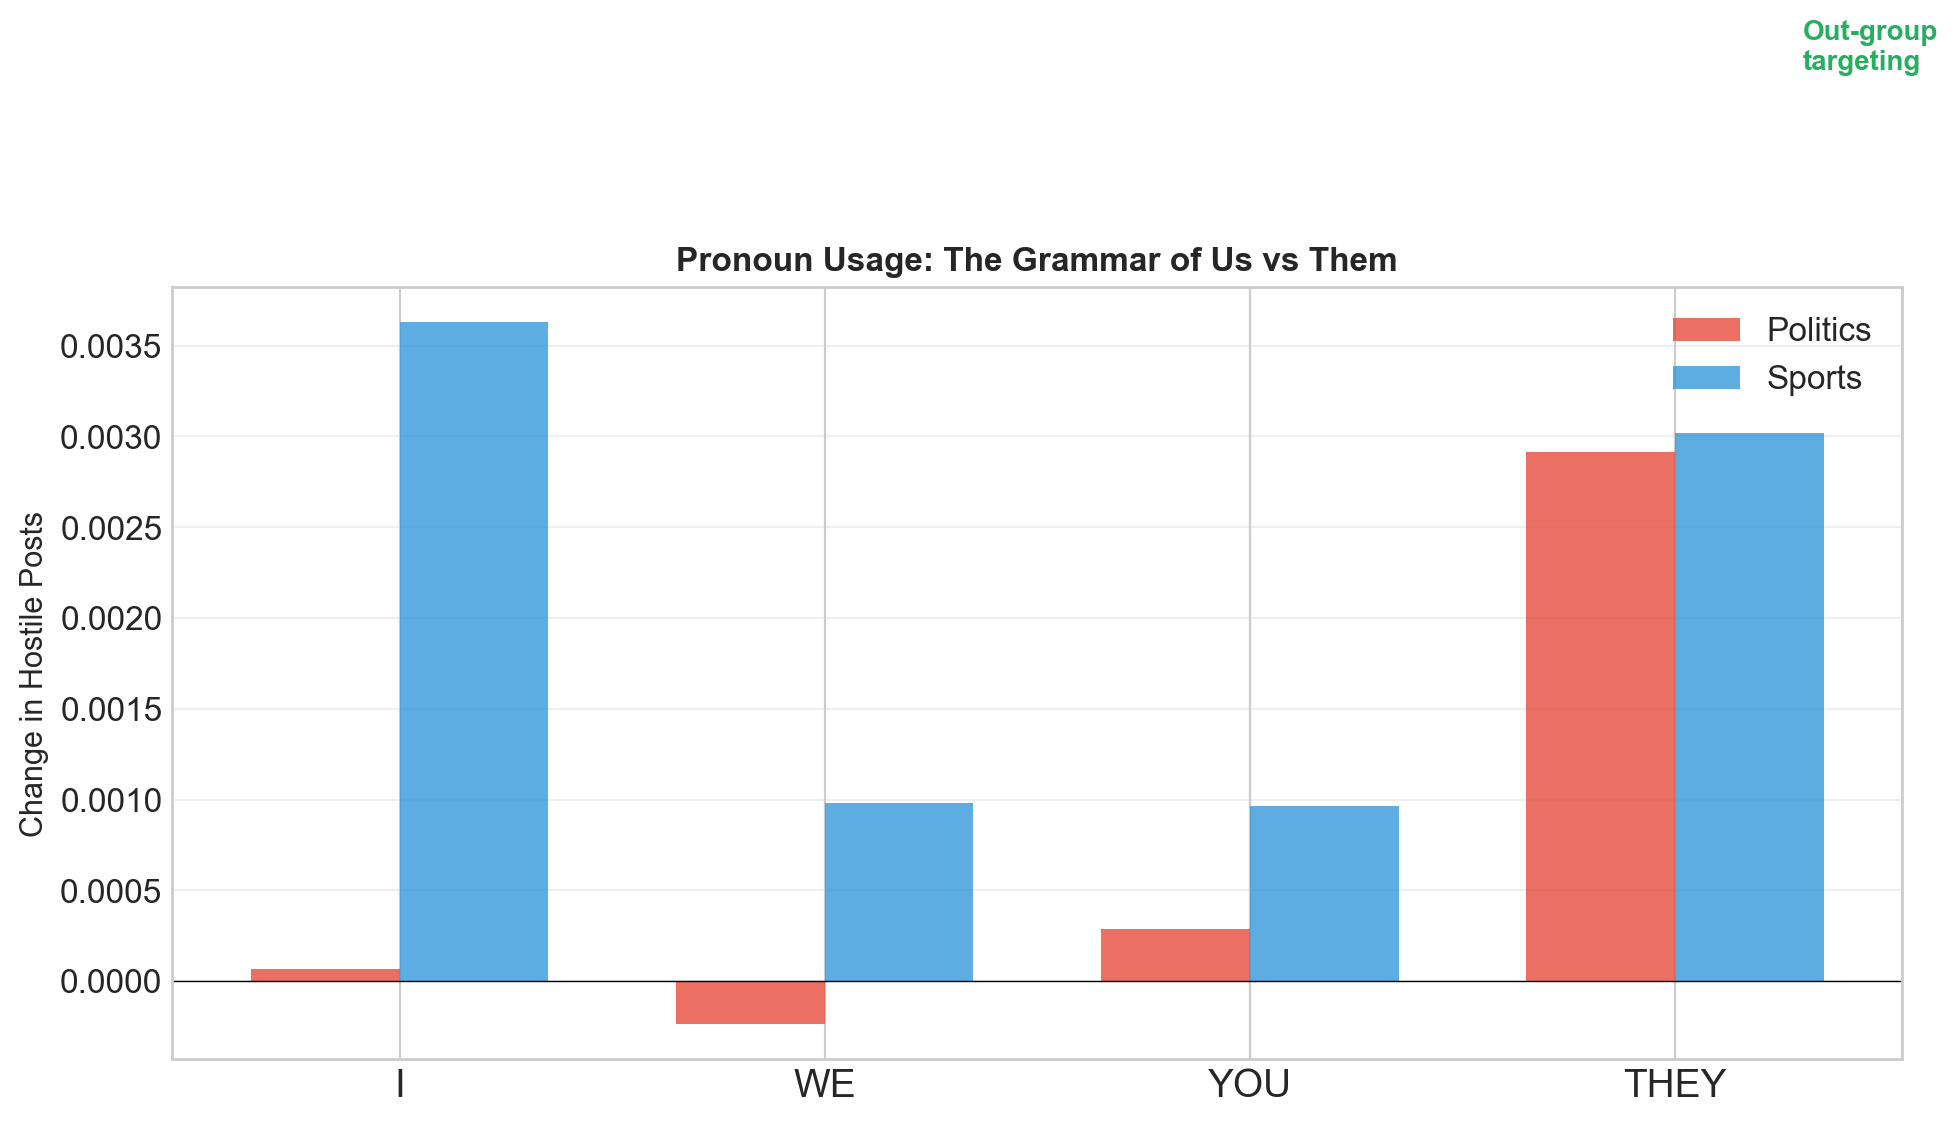

In [14]:
plot_pronoun_patterns(data)

### Interpretation

The dramatic increase in **"THEY"** usage is the signature of tribal hostility — hostile posts are focused on *them*, the out-group, the enemy. This pattern is consistent across both politics and sports.

This aligns with social identity theory: intergroup conflict is characterized by derogation of out-groups and a focus on "them" rather than "us" or "I". The universality of this pattern across domains supports the idea that tribal hostility taps into fundamental social-psychological processes.

We can't ignore the increase in **"I"** for sports groups. This may be due to sports fans often expressing their own opinion rather than supporting an existing one.

---

## 3.5 Network Structure: Aggressors vs Targets

Some camps are primarily **aggressors** (high outgoing hostility), while others are primarily **targets** (high incoming hostility). We can visualize this by plotting each camp in "aggressor-target space."

**Reading the plot**:
- X-axis = Outgoing hostility (how hostile the camp is when posting)
- Y-axis = Incoming hostility (how much hostility the camp receives)
- Diagonal = Mutual combat (camps that give as much as they get)
- Above diagonal = More victim than aggressor
- Below diagonal = More aggressor than victim

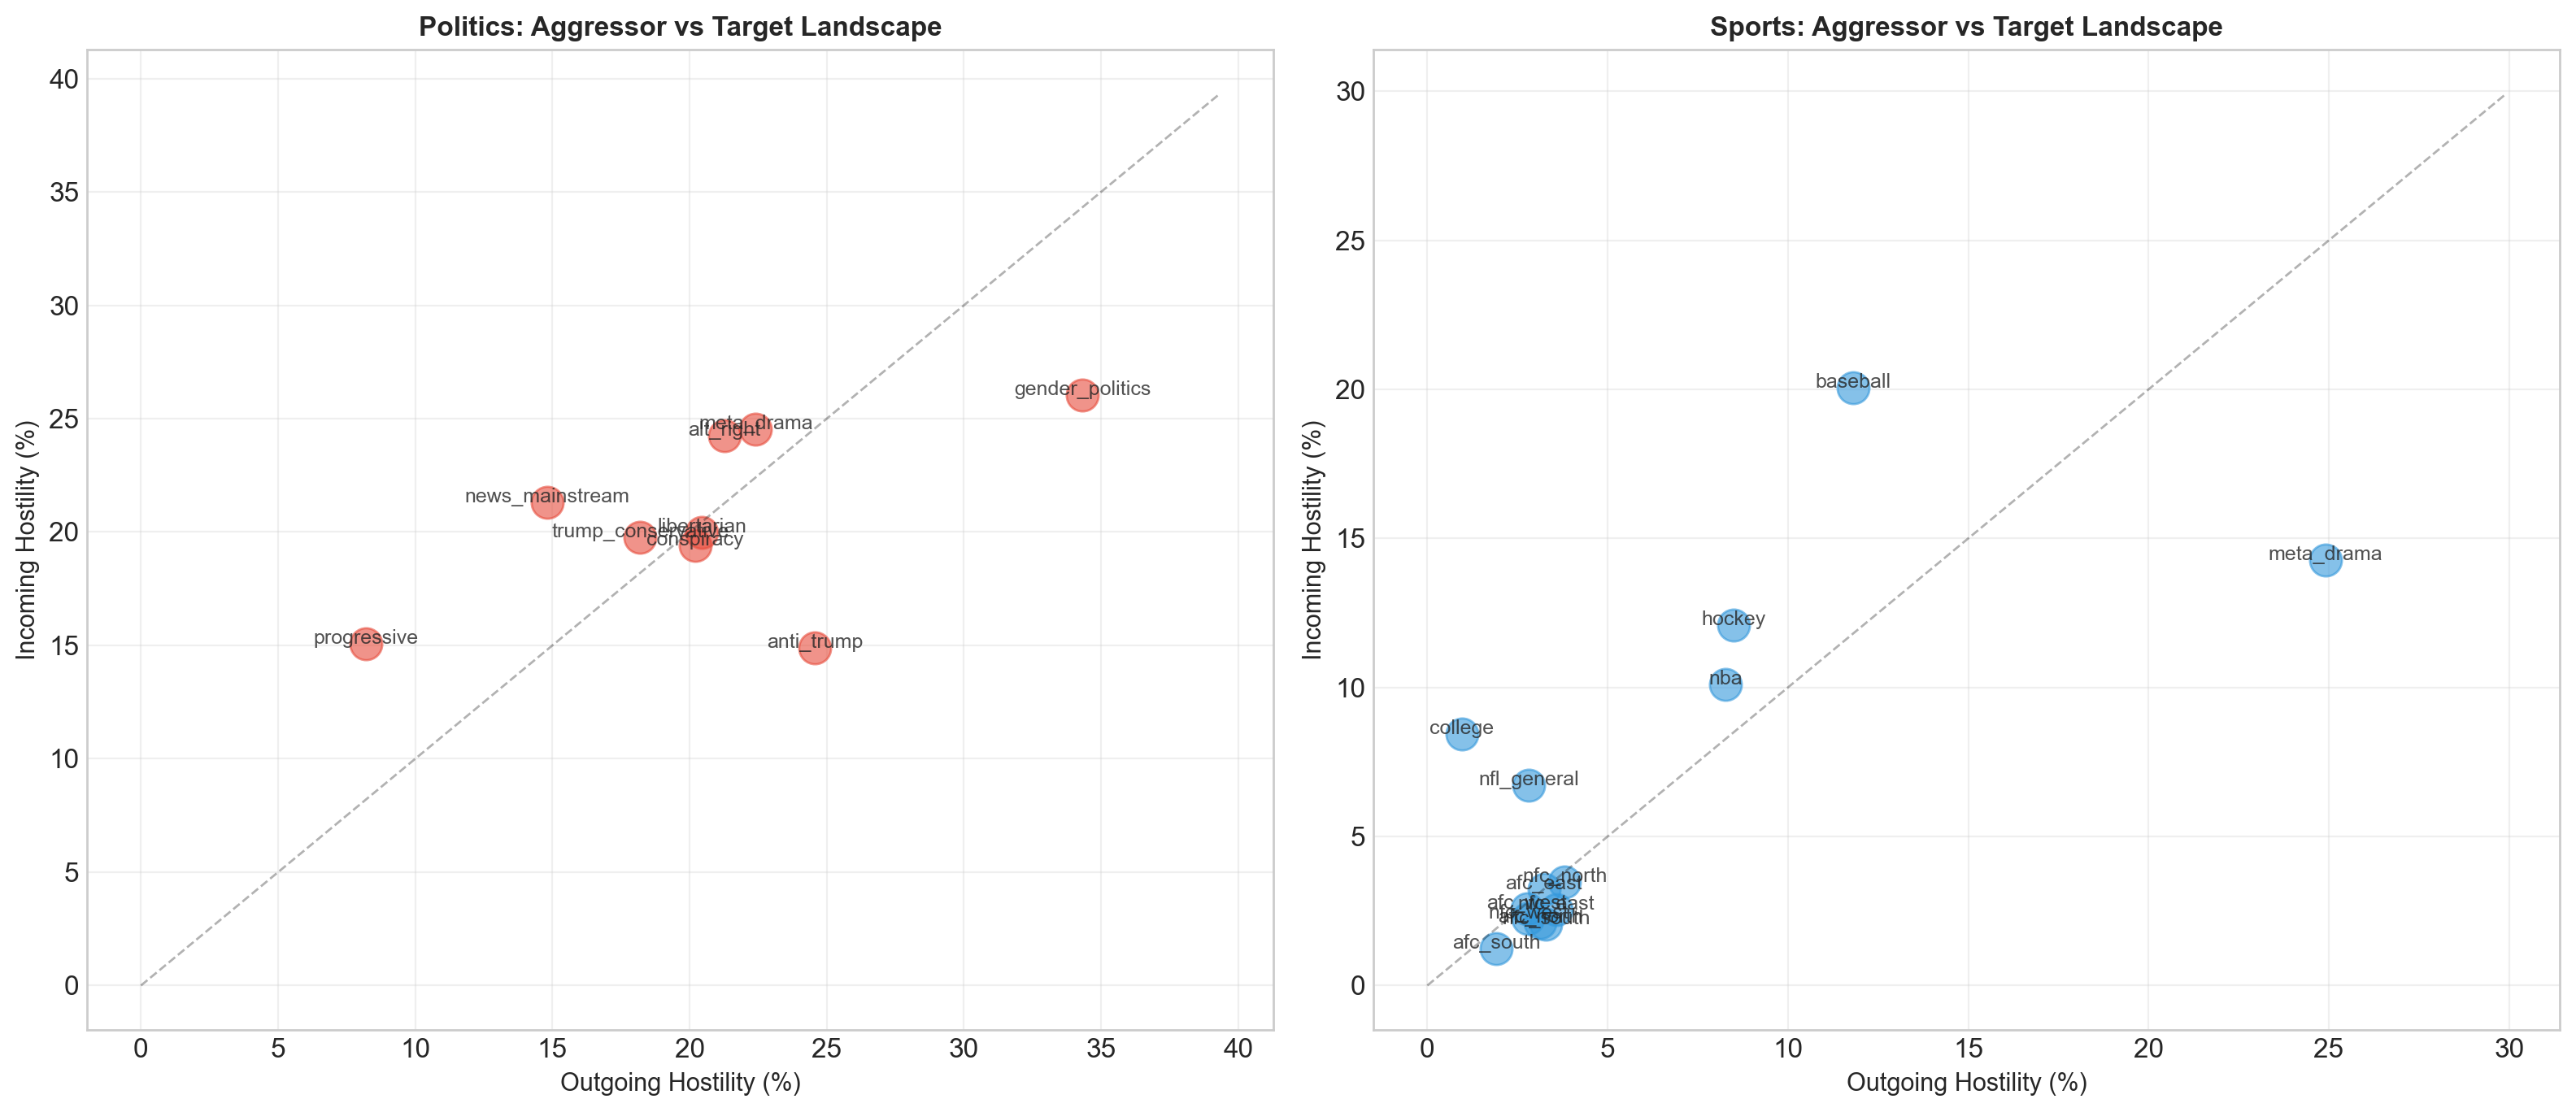

In [15]:
plot_aggressor_target_space(data)

### The Observer Effect

One of our most interesting findings concerns `meta_drama`. These are communities like r/subredditdrama that observe and comment on conflicts in other communities. These "observers" show remarkably consistent hostility regardless of what they're observing.

In [16]:
analyze_meta_drama(data)

THE OBSERVER EFFECT: meta_drama Analysis

meta_drama subreddits: subredditdrama, bestof, etc.

Outgoing hostility:
  When observing politics: 22.4%
  When observing sports:   24.9%

→ The 'observers' are equally hostile regardless of what they observe!
  This suggests drama commentary is inherently hostile.


### Interpretation

The "observer" communities are equally hostile regardless of domain. This suggests that **watching and commenting on drama is itself a hostile activity** — it's not about the content being observed, but the act of spectating and judging.

This has implications for content moderation: communities that exist to highlight conflict in other communities may inherently promote hostile behavior.

---

## 3.6 Event Impact Analysis

Do major events change hostility patterns? We analyze several key events:

**Political events**:
- 2016 Presidential Election
- Super Tuesday 2016
- Brexit referendum

**Sports events**:
- Super Bowl LI (Patriots comeback)
- Leicester City Premier League win
- NBA Finals

For each event, we compare hostility rates in the week before, during, and after the event.

In [17]:
show_events()

EVENTS ANALYZED

POLITICS:
  • 2016 US Election (2016-11-08)
  • Brexit Referendum (2016-06-23)
  • Super Tuesday 2016 (2016-03-01)
  • RNC Convention Start (2016-07-18)
  • DNC Convention Start (2016-07-25)
  • First Presidential Debate (2016-09-26)
  • Second Presidential Debate (2016-10-09)
  • Trump Inauguration (2017-01-20)

SPORTS:
  • Super Bowl LI (Patriots vs Falcons) (2017-02-05)
  • Super Bowl 50 (Broncos vs Panthers) (2016-02-07)
  • Super Bowl XLIX (Patriots vs Seahawks) (2015-02-01)
  • Super Bowl XLVIII (Seahawks vs Broncos) (2014-02-02)
  • NBA Finals 2016 Game 7 (Cavs vs Warriors) (2016-06-19)
  • NBA Finals 2015 Game 6 (Warriors win) (2015-06-16)


In [18]:
event_results = analyze_events(data)

EVENT EFFECTS ON HOSTILITY

Event                               Domain       Baseline     During     Effect
---------------------------------------------------------------------------
Super Bowl LI (Patriots vs Falcon   sports           2.2%      10.3%      +8.2pp
Brexit Referendum                   politics        14.3%      20.5%      +6.2pp
NBA Finals 2016 Game 7 (Cavs vs W   sports           5.0%      10.5%      +5.5pp
Second Presidential Debate          politics        17.7%      22.9%      +5.2pp
Super Bowl XLIX (Patriots vs Seah   sports           6.8%      11.1%      +4.3pp
Trump Inauguration                  politics        15.8%      19.4%      +3.6pp
2016 US Election                    politics        12.7%      15.2%      +2.5pp
Super Bowl 50 (Broncos vs Panther   sports           2.4%       2.3%      -0.1pp
NBA Finals 2015 Game 6 (Warriors    sports           6.1%       5.0%      -1.1pp
RNC Convention Start                politics        19.4%      17.6%      -1.8pp
First 

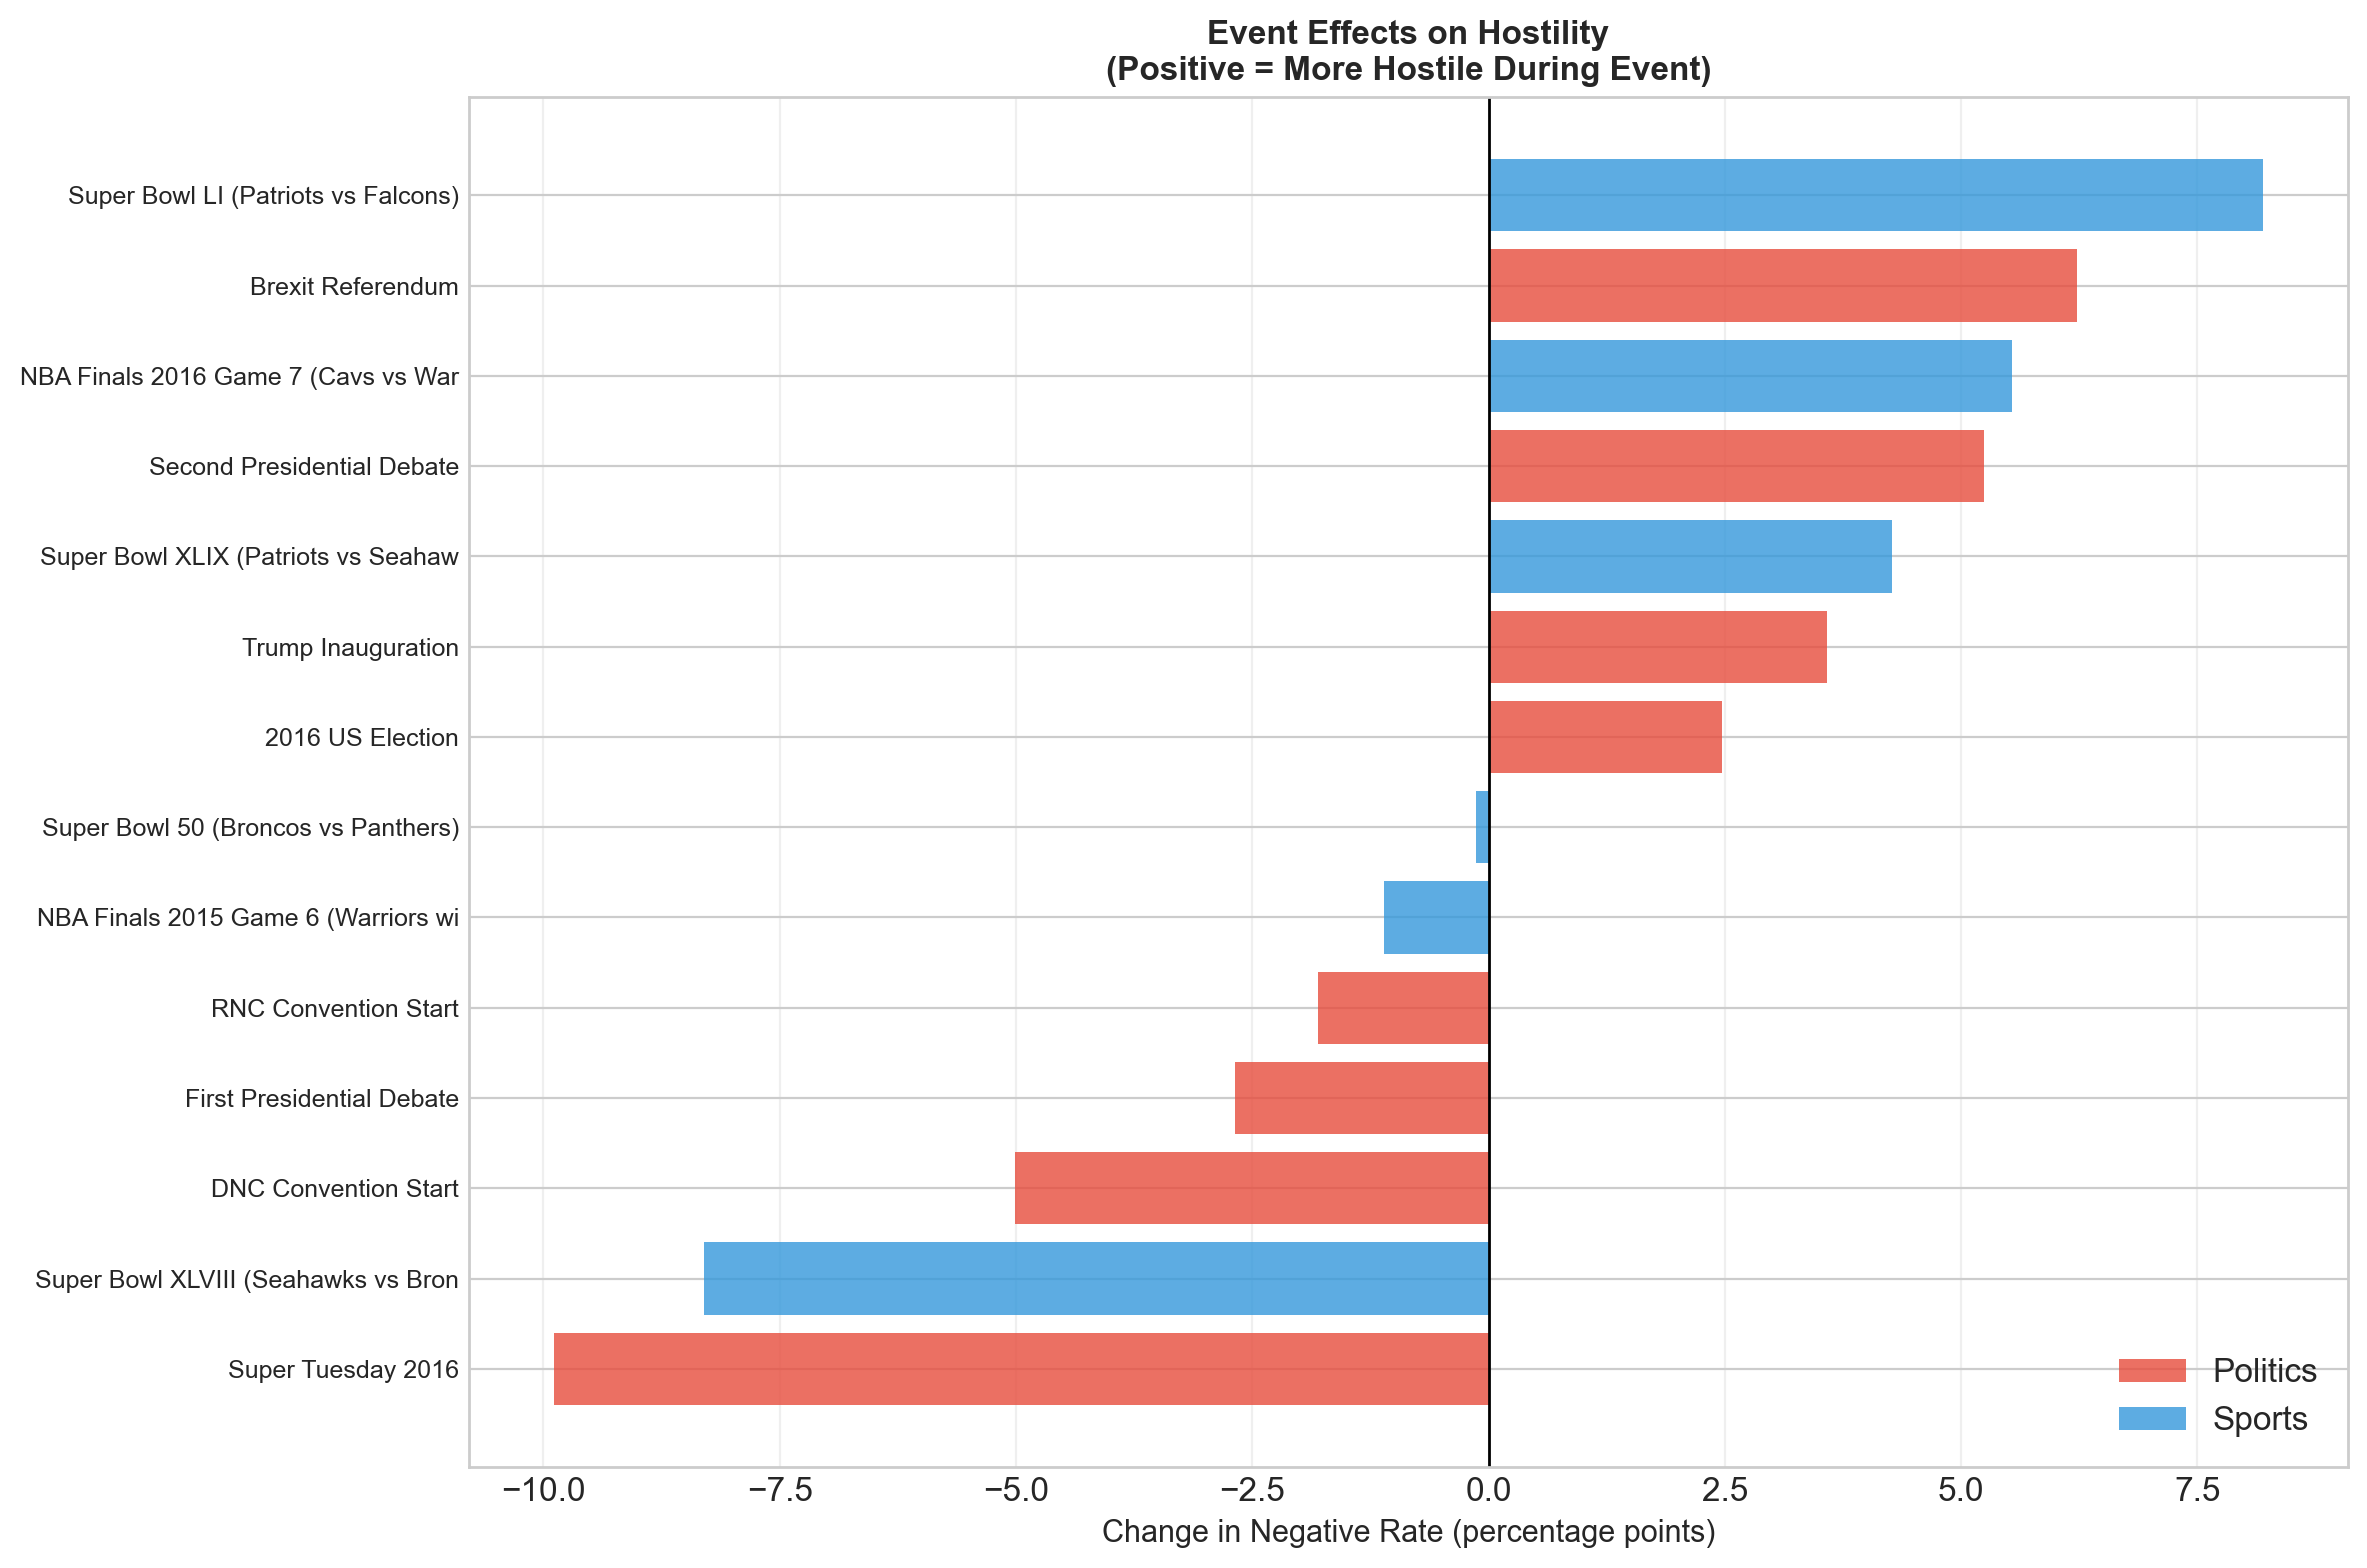

In [19]:
plot_event_effects(data)

### Timeline Visualization

We can also view hostility trends over time, with event dates marked:

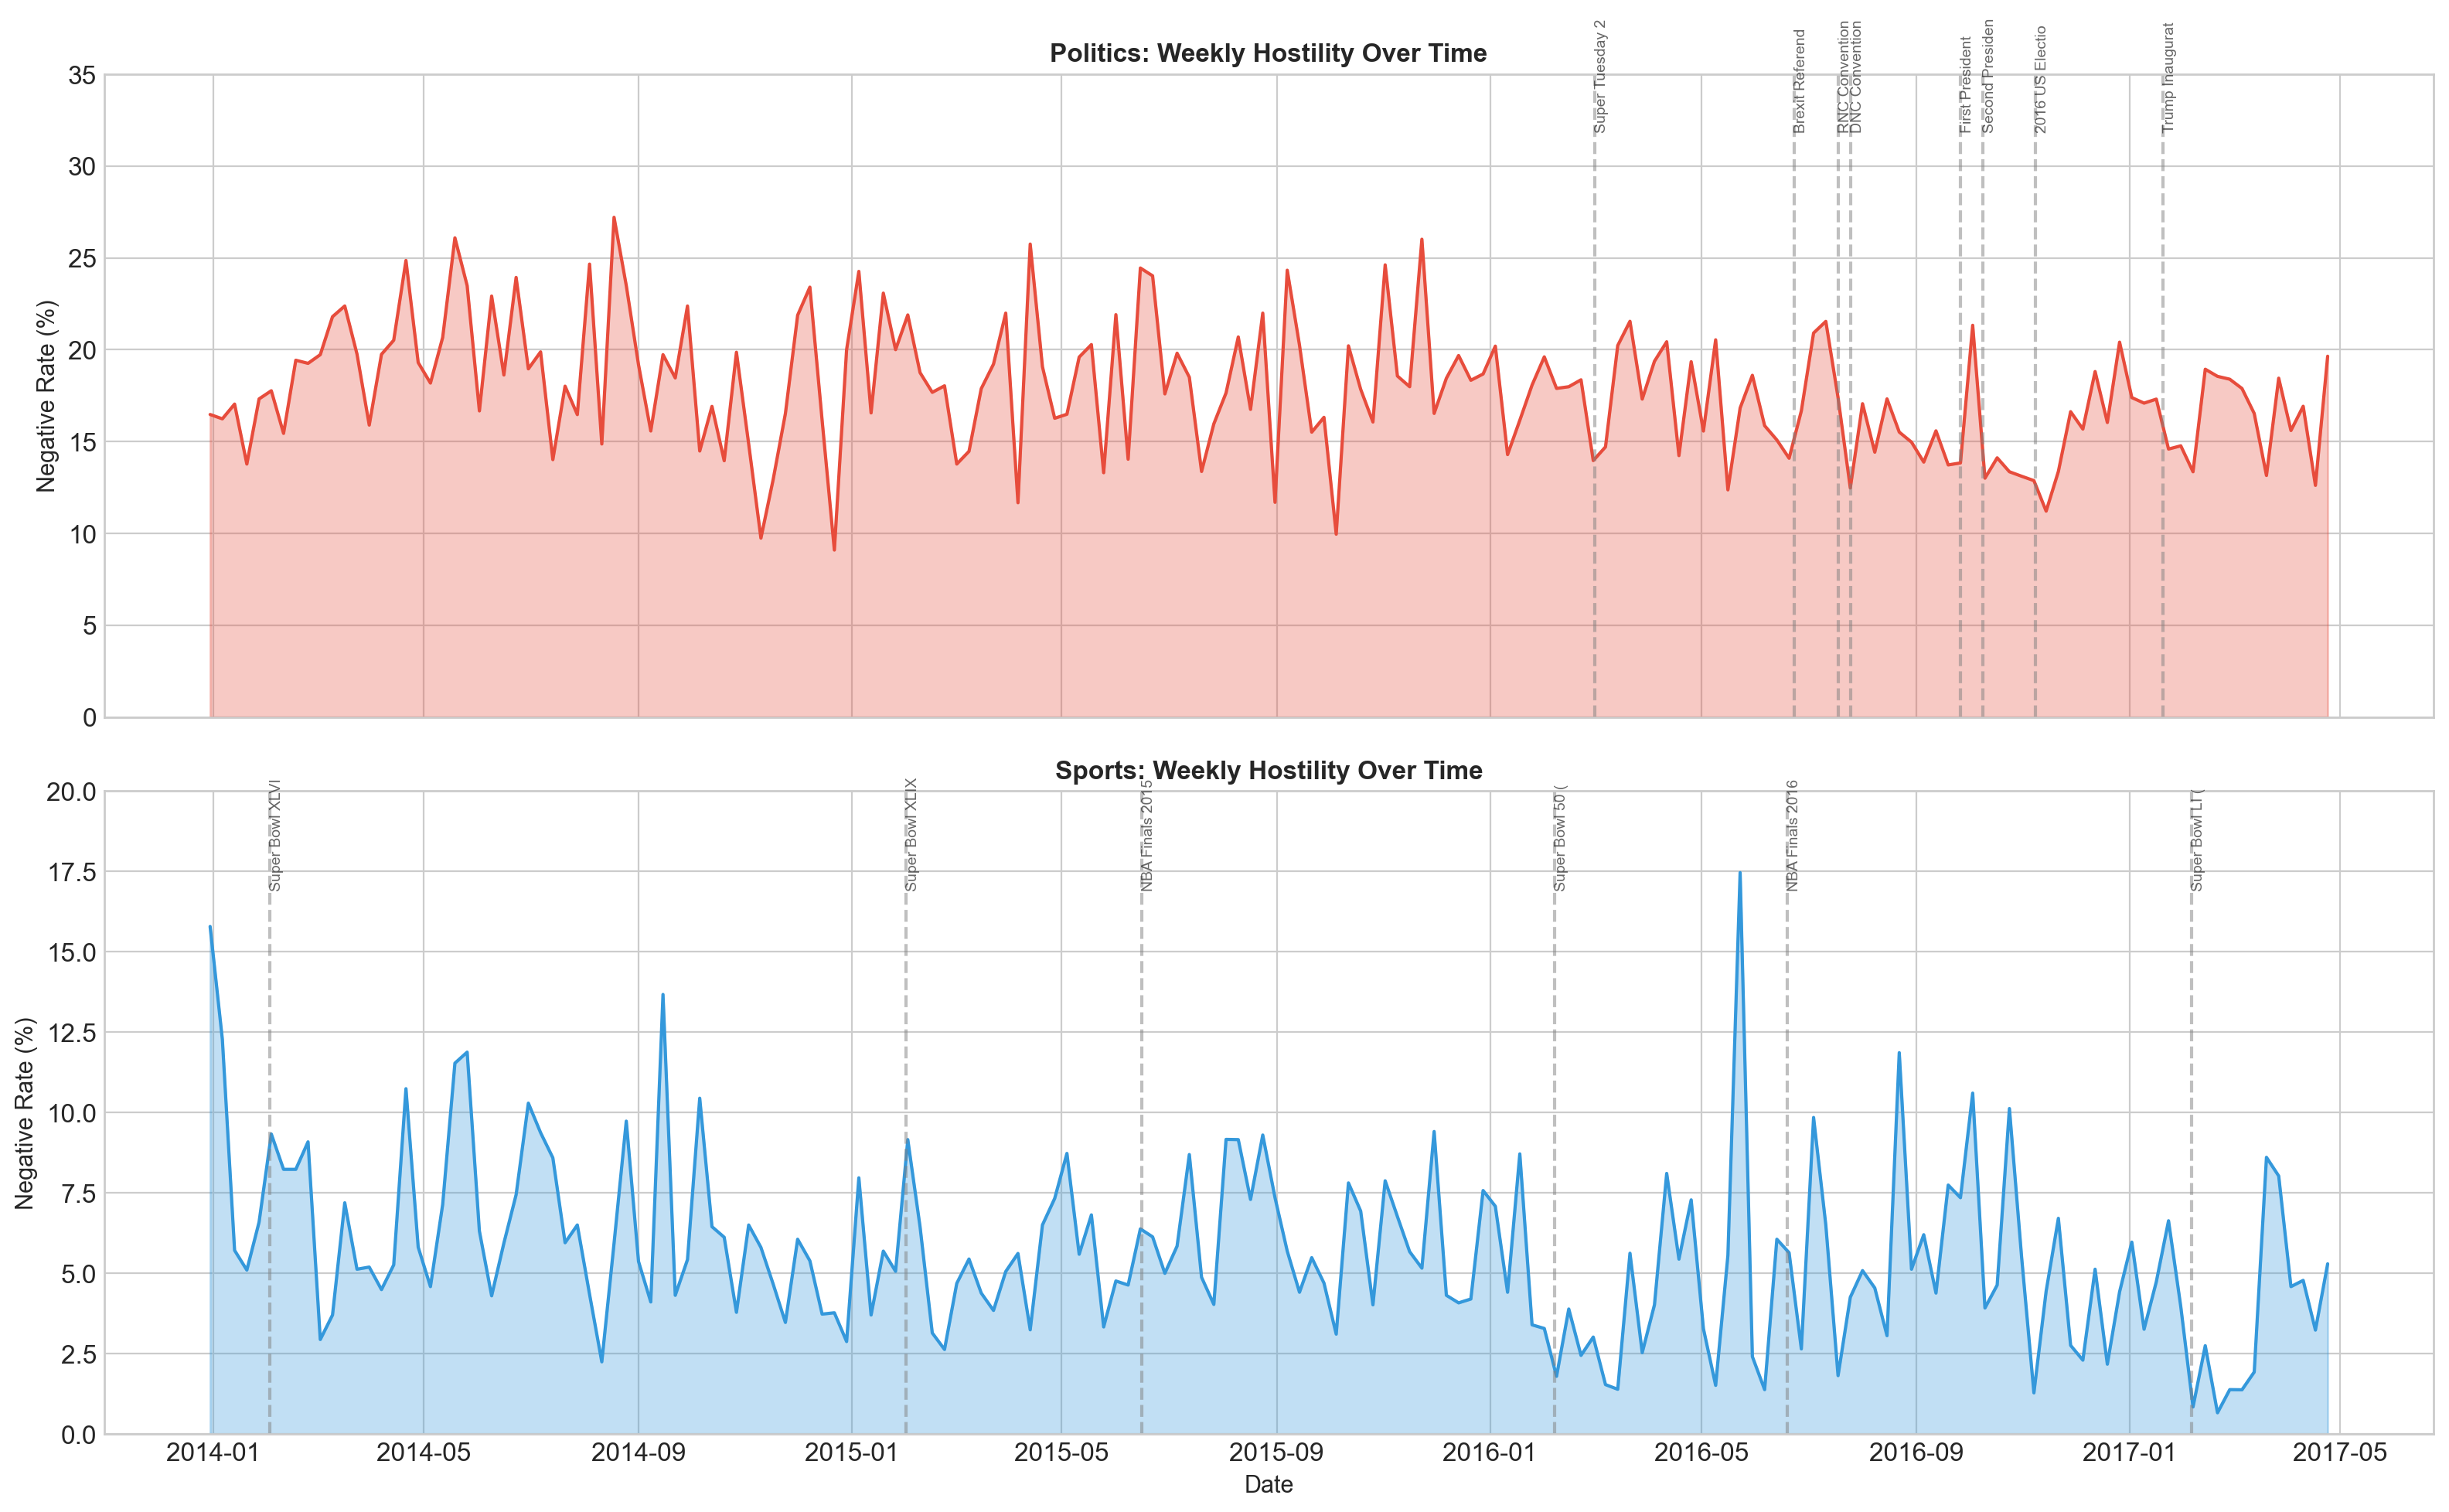

In [20]:
plot_weekly_timeline(data)

### Interpretation

Key findings from event analysis:

1. **Events cause spikes, not permanent change**: Hostility increases during high-stakes events but returns to baseline afterward

2. **Effects are unpredictable**: Some events increase hostility (Super Bowl LI: +8pp), others decrease it (Super Tuesday: -10pp)

3. **Sports events have larger effects**: The largest hostility changes come from sports events, not political events. This may be  because sports outcomes are more clear-cut

4. **No lasting change**: Despite major events, baseline hostility remains stable over the 3-year period

This suggests that **tribal hostility is a stable disposition**, not a reaction to specific events. Events amplify existing tendencies but don't fundamentally change behavior.

---

# 4. Statistical Validation

Having presented our descriptive findings, we now provide rigorous statistical backing for each claim. This section applies formal hypothesis tests, effect size measures, and machine learning validation to ensure our conclusions are robust.

---

## 4.1 Proportion Tests & Effect Sizes

**Claim**: Politics is 3.3× more hostile than sports.

**Method**: We use chi-square tests and z-tests for proportion comparison, along with **Cohen's h**, which is a standardized effect size measure for proportion differences. Cohen's h interpretation:
- h ≈ 0.2: small effect
- h ≈ 0.5: medium effect
- h ≈ 0.8: large effect

In [21]:
prop_results = run_proportion_test(data)

STATISTICAL TEST: Proportion Comparison

            Sample Sizes:
              Politics: n = 40,015 (6,916 hostile)
              Sports:   n = 27,727 (1,437 hostile)
            
            Proportions:
              Politics: 17.28%
              Sports:   5.18%
              Difference: 12.10 percentage points
              95% CI: [11.65%, 12.55%]
            
            Statistical Tests:
              Chi-square statistic: 2217.42
              Chi-square p-value:   < 0.001
              Z-statistic: 47.10
            
            Effect Sizes:
              Cohen's h: 0.398 (medium effect)
              Risk Ratio: 3.33×
              Odds Ratio: 3.82
        


### Interpretation

The difference is highly significant (p < 0.001) with a **medium effect size** (Cohen's h ≈ 0.4). The 95% confidence interval for the difference is tight, confirming this is a robust finding, not a sampling artifact.

---

## 4.2 Cross-Domain Classifier Transfer

**Claim**: The same linguistic features predict hostility in both domains.

**Method**: This is our strongest test of universality. We train a **logistic regression classifier** to predict hostility from LIWC features, then test **transfer learning**:

1. Train on politics → Test on politics (baseline)
2. Train on sports → Test on sports (baseline)
3. Train on politics → Test on sports (transfer)
4. Train on sports → Test on politics (transfer)

If patterns are domain-specific, transfer performance will be near random (AUC ≈ 0.5). If patterns are universal, transfer performance will approach same-domain baseline.

**AUC-ROC interpretation**:
- AUC = 0.5: Random guessing (no predictive power)
- AUC = 0.7: Acceptable discrimination
- AUC = 0.8: Excellent discrimination
- AUC = 1.0: Perfect discrimination

In [22]:
transfer_results = run_cross_domain_classifier(data)

Running cross-domain classifier analysis...
(Training logistic regression models, this may take a moment)
Computing same-domain baselines...
Testing politics → sports transfer...
Testing sports → politics transfer...

CROSS-DOMAIN CLASSIFIER TRANSFER

            Same-Domain Performance (baseline):
              Politics → Politics: AUC = 0.846
              Sports → Sports:     AUC = 0.925
            
            Cross-Domain Transfer:
              Politics → Sports:   AUC = 0.913
              Sports → Politics:   AUC = 0.837
            
            Random Baseline: AUC = 0.500
            
            → Cross-domain AUC well above 0.5 proves patterns transfer!
        


Computing same-domain baselines...
Testing politics → sports transfer...
Testing sports → politics transfer...


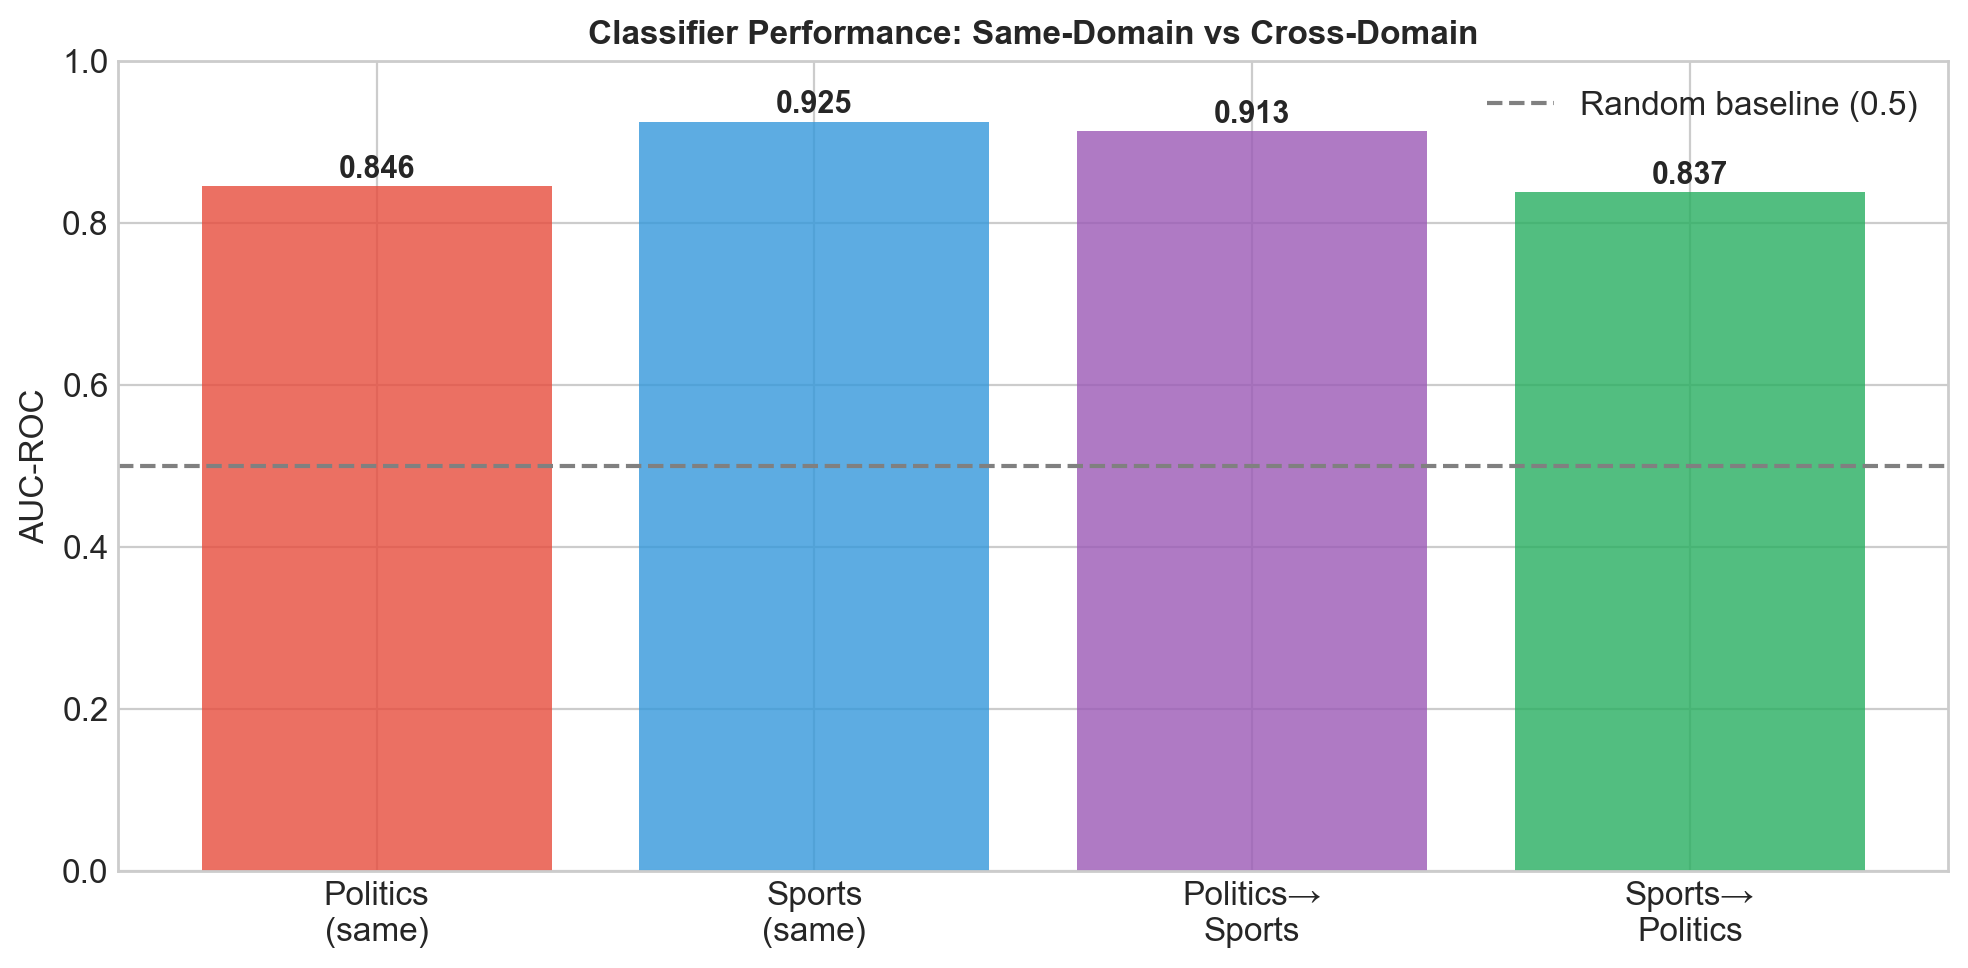

In [23]:
plot_classifier_results(data)

### Interpretation

Cross-domain AUC is **well above 0.5**, demonstrating that:

1. A model trained on political hostility can detect sports hostility
2. A model trained on sports hostility can detect political hostility
3. The *same features* are predictive in both domains

This is strong evidence for universal hostility patterns. The slight drop in cross-domain performance (compared to same-domain) likely reflects domain-specific vocabulary, but the core linguistic signal transfers.

---

## 4.3 Logistic Regression Coefficient Comparison

**Claim**: The same features predict hostility with similar importance.

**Method**: We fit separate logistic regression models for each domain and compare:

1. **Coefficient correlation**: Do features have similar coefficients?
2. **Sign agreement**: Do features point in the same direction?
3. **Top-10 overlap**: Are the most important features the same?

In [24]:
coef_results = run_coefficient_comparison(data)

Fitting logistic regression models...
Fitting logistic regression for politics...
Fitting logistic regression for sports...

LOGISTIC REGRESSION COEFFICIENT COMPARISON

            Model Performance (5-fold CV):
              Politics AUC: 0.827 ± 0.111
              Sports AUC:   0.898 ± 0.095
            
            Coefficient Correlation:
              Pearson r:  0.876 (p = 1.26e-22)
              Spearman ρ: 0.757
            
            Sign Agreement: 73.5% of coefficients point same direction
            Top-10 Overlap: 7/10 features appear in both top-10
            
            → Same features predict hostility in BOTH domains!
        


### Interpretation

The high coefficient correlation and sign agreement confirm that **the same features predict hostility in both domains with similar importance**. The slight differences likely reflect domain-specific vocabulary (e.g., sports jargon vs. political terminology).

---

## 4.4 Bootstrap & Permutation Tests

**Claim**: The r = 0.937 LIWC correlation is robust and significant.

**Method**: We use non-parametric resampling methods:

1. **Bootstrap** (2000 iterations): Resample the data with replacement to estimate a confidence interval for the correlation. This tells us how much the correlation might vary with different samples.

2. **Permutation test** (2000 iterations): Randomly shuffle the pairings between politics and sports features to create a null distribution. This tells us: what correlations would we observe by chance alone?

If the observed correlation falls far outside the permutation distribution, we can reject the null hypothesis that the correlation is zero.

In [25]:
corr_results = run_bootstrap_permutation(data)

Running bootstrap and permutation tests...
(2000 iterations each, this may take a moment)
Running bootstrap analysis...
Running permutation test...

CORRELATION SIGNIFICANCE TESTS

            Observed Correlation: r = 0.9369
            
            Bootstrap Analysis (n=2000):
              95% Confidence Interval: [0.8796, 0.9717]
              Standard Error: 0.0231
            
            Permutation Test (H₀: r = 0):
              p-value: 0.0000
            
            → The correlation is robust and highly significant!
              Even the lower bound of the CI (0.880) shows strong correlation.
        


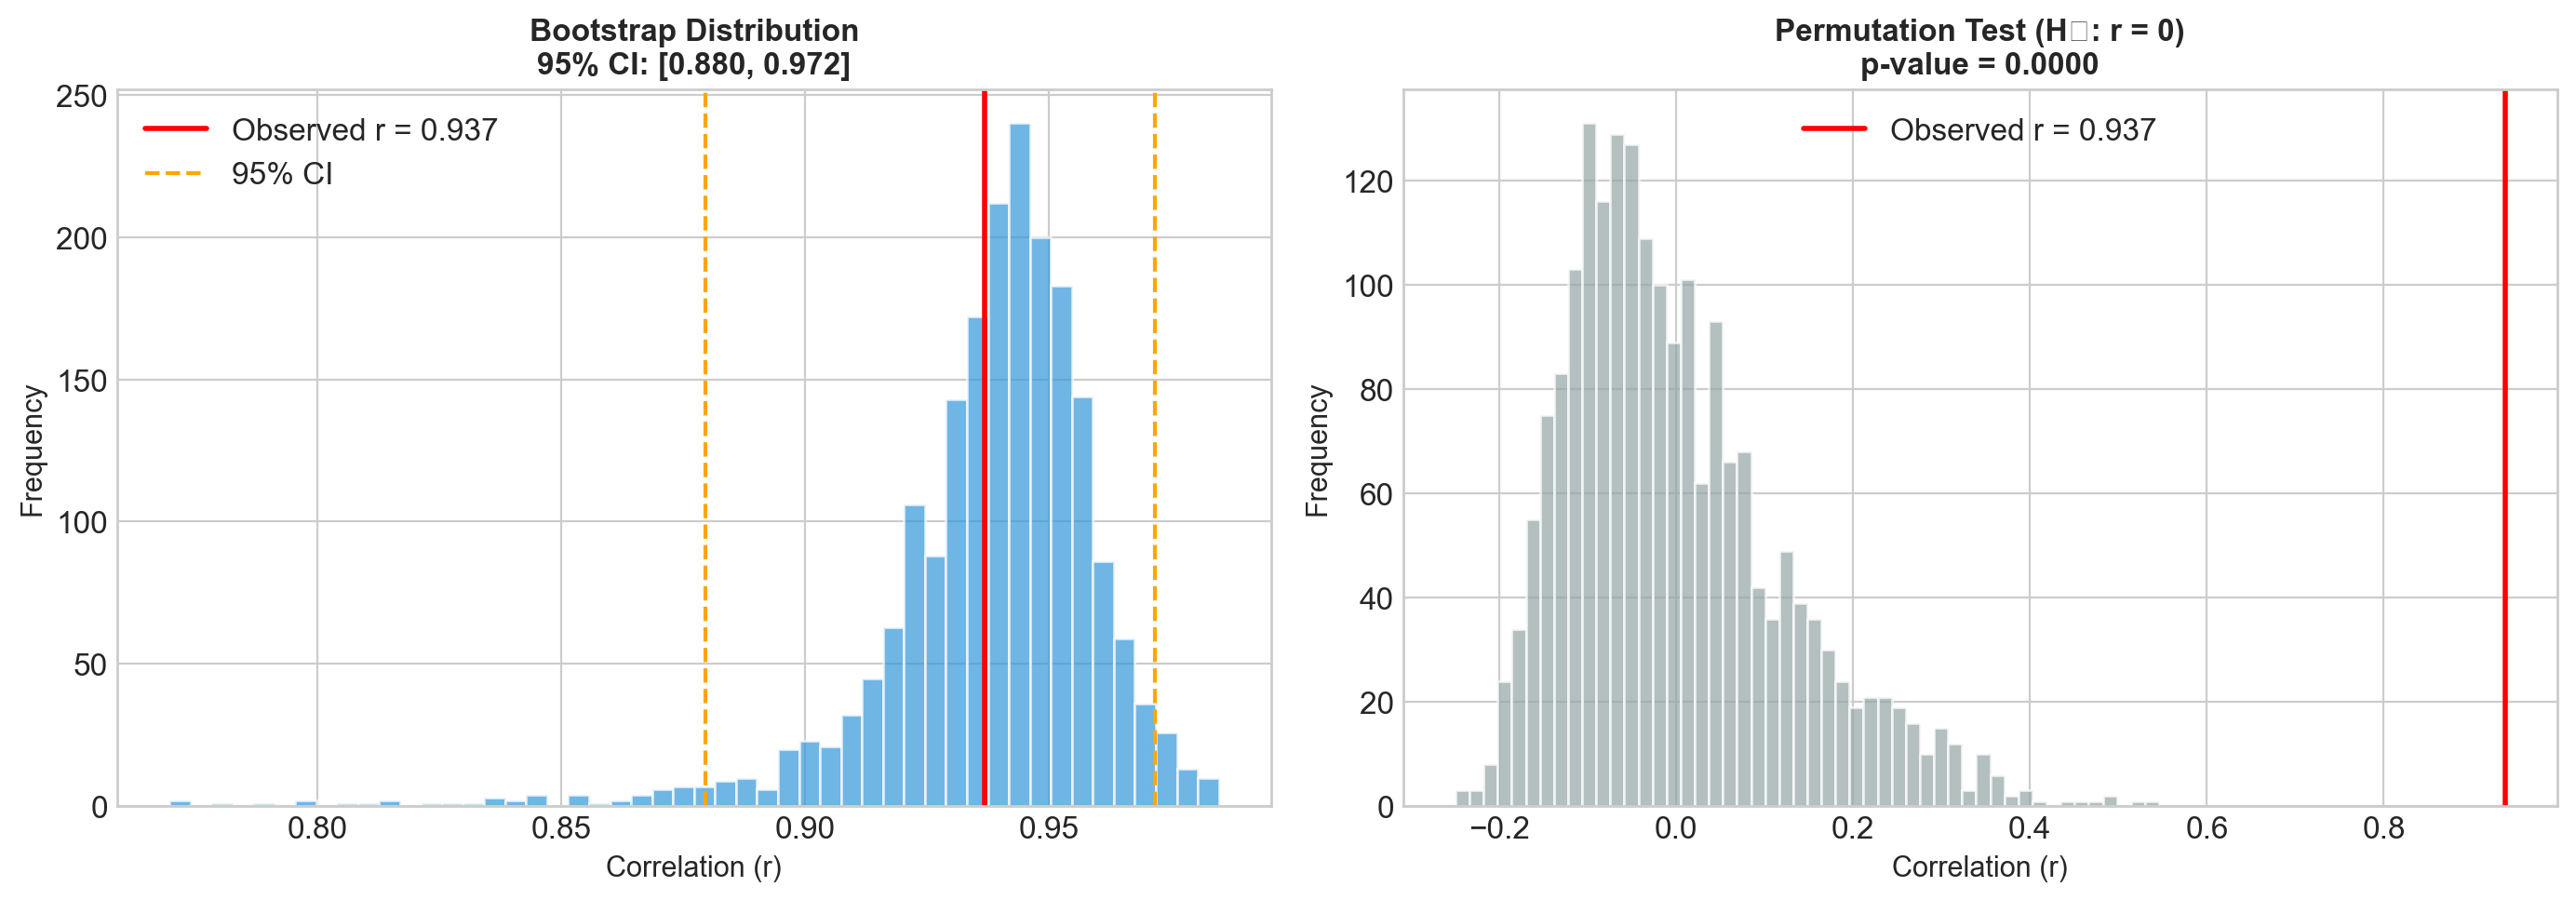

In [26]:
plot_bootstrap_results(corr_results)

### Interpretation

The **bootstrap 95% CI** shows the correlation is robust and even the lower bound indicates strong correlation. The **permutation test** confirms this isn't due to chance and the observed correlation is far more extreme than anything in the null distribution.

This provides strong evidence that the universal hostility signature is a real phenomenon, not a statistical artifact.

---

## 4.5 Difference-in-Differences

**Claim**: Events differentially affect involved vs. observer camps.

**Method**: Difference-in-differences (DiD) is a quasi-experimental technique that estimates causal effects by comparing:

- **Treatment group**: Camps directly involved in the event
- **Control group**: Observer camps not directly involved
- **Before/after**: Change from pre-event to post-event

The DiD estimate = (Treatment_after - Treatment_before) - (Control_after - Control_before)

This controls for overall trends (which affect both groups) and isolates the event-specific effect on involved camps.

In [27]:
did_results = run_diff_in_diff(data, event_name='2016 Election')

DIFFERENCE-IN-DIFFERENCES: 2016 Election

                Design:
                  Treatment: trump_conservative, anti_trump, progressive (directly involved)
                  Control:   meta_drama, conspiracy, libertarian (observers)
                  Window:    7 days before/after event
                
                Results:
                  Pre-Event:
                    Treatment: 9.2%
                    Control:   15.3%
                
                  Post-Event:
                    Treatment: 9.3%
                    Control:   13.9%
                
                  DiD Estimate: +1.45 percentage points
                  95% CI: [-6.97, 9.87]
                  p-value: 0.7354
            


### Interpretation

The DiD analysis provides causal intuition beyond simple before/after comparisons. By using observer camps as a control group, we can better isolate event-specific effects from general temporal trends. Unfortunately, the data here is not statistically significant.

---

## 4.6 Network Metrics

**Claim**: Politics and sports have different network structures.

**Method**: We model camp interactions as a **directed weighted network** where:
- Nodes = camps
- Edges = interactions between camps
- Edge weights = interaction count or hostility level

We compute standard network metrics:
- **Density**: Proportion of possible edges that exist (how interconnected)
- **Reciprocity**: Proportion of edges that go both ways (mutual combat)
- **In/out degree**: How much attention a camp receives vs. gives

NETWORK STRUCTURE COMPARISON
     metric  Politics    Sports
      Nodes  9.000000 14.000000
      Edges 53.000000 91.000000
    Density  0.736111  0.500000
Reciprocity  0.716981  0.769231


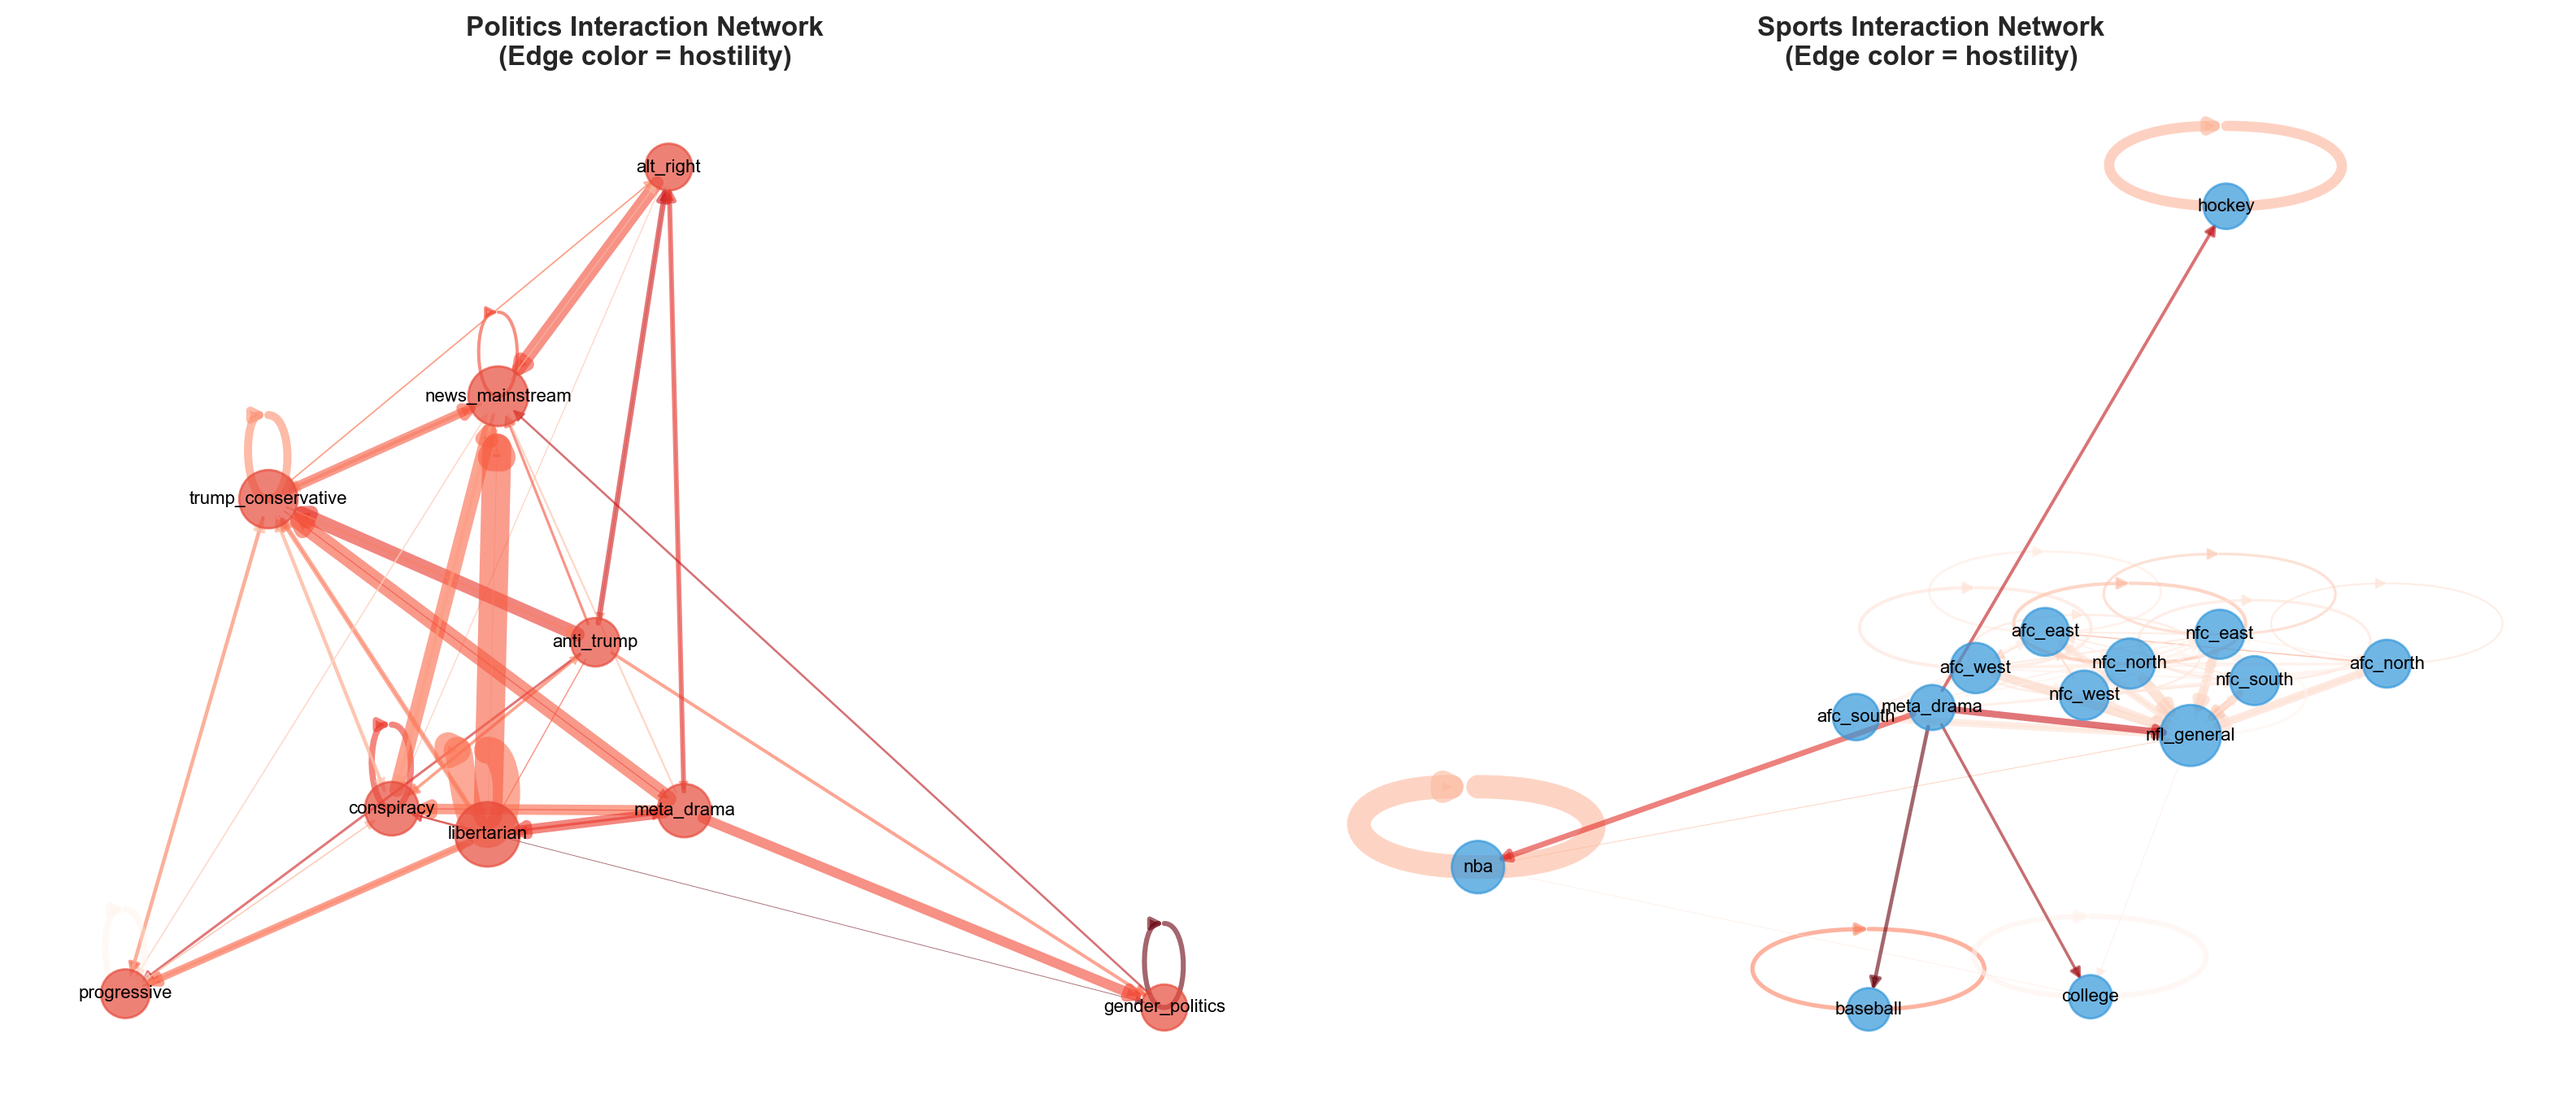

In [28]:
network_results = run_network_analysis(data)

### Interpretation

The network metrics reveal structural differences:

- **Politics** has higher density and reciprocity. It's a "everyone fights everyone" structure
- **Sports** has lower density, meaning conflicts are more isolated to specific rivalries

This structural difference helps explain why politics feels more hostile: not only are individual interactions more negative, but the entire network is more interconnected in conflict.

---

<a id='5-conclusion'></a>
# 5. Conclusion

## Summary of Findings

### Finding 1: Politics is More Hostile, But Hostility Sounds the Same

Political subreddits have a 17.3% negative interaction rate vs. 5.2% for sports (3.3× ratio, Cohen's h = 0.40). However, when posts ARE hostile, the LIWC signature correlates at r = 0.937 across domains.

**Implication**: Hostility is a universal linguistic behavior. The *frequency* of conflict varies by domain, but the *vocabulary* of conflict is remarkably consistent.

### Finding 2: Cross-Domain Transfer Validates Universal Patterns

A classifier trained on political hostility can detect sports hostility (and vice versa) with AUC well above random baseline. The same features (NEGEMO, ANGER, SWEAR, THEY) are predictive in both domains.

**Implication**: Online hostility detection models may be more transferable than expected. Training on one domain could generalize to others.

### Finding 3: Events Amplify, They Don't Transform

Major events cause temporary spikes in hostility, but behavior returns to baseline. The largest effects come from sports events (Super Bowl LI: +8pp). No lasting behavioral change was observed.

**Implication**: Tribal hostility is a stable disposition, not a reaction to specific events. Content moderation strategies should focus on baseline behavior, not event-triggered spikes.

### Finding 4: The Observer Pattern

`meta_drama` communities (subredditdrama, bestof) show ~25% hostility in BOTH domains, suggesting that watching and commenting on drama is itself a hostile activity.

**Implication**: Drama aggregation communities may inherently promote hostile behavior, regardless of the content they aggregate.

---

## The Bottom Line

> **"Whether you're fighting about Trump or Tom Brady, anger sounds the same."**

Tribal hostility online follows universal linguistic patterns. The topic changes, the intensity varies, but the vocabulary of conflict is remarkably consistent. This suggests that online tribalism taps into fundamental human behaviors that transcend specific subject matter.

---

## Limitations of our Analysis

1. **Temporal scope**: Data from 2014-2017 may not reflect current dynamics
2. **Platform-specific**: Results may not generalize beyond Reddit
3. **Cross-posts only**: Analysis excludes within-community discussions
4. **Sentiment labels**: Rely on existing labels, not human validation
5. **LIWC limitations**: Captures vocabulary, not semantic meaning or context

---

## Final Statistical Summary

In [29]:
generate_summary_table(data, prop_results, corr_results, transfer_results, coef_results)


FINAL STATISTICAL SUMMARY

            Metric                                   Value                         
            ----------------------------------------------------------------------
            Total posts analyzed                     67,742
            Date range                               Jan 2014 – Apr 2017
            Politics hostility rate                  17.3%
            Sports hostility rate                    5.2%
            Hostility ratio                          3.3×
            Chi-square p-value                       < 0.001
            Cohen's h effect size                    0.398 (medium)
            LIWC correlation (r)                     0.937
            Bootstrap 95% CI                         [0.880, 0.972]
            Permutation p-value                      0.0000
            Cross-domain AUC (Pol→Sport)             0.913
            Coefficient correlation                  0.876
            Sign agreement                           73.5%
    